Analisi delle violazioni SLA sul dataset worst-case dei datapacket.

* **`Distribution`**: la distribuzione statistica usata nella simulazione per generare la variabilità del modello.

* **`Scenario`**: lo scenario simulato a cui appartiene l’osservazione; identifica una specifica configurazione del sistema.

* **`App_ms`**: identificativo completo dell’applicazione o catena di microservizi considerata.

* **`App_group`**: versione aggregata di `App_ms` che ignora il prefisso numerico iniziale e mantiene solo la struttura dell’applicazione.

* **`Run`**: identificativo della singola run di simulazione.

* **`User`**: identificativo dell’utente associato al datapacket o alla richiesta.

* **`Application`**: identificativo numerico dell’applicazione coinvolta.

* **`Total Delay`**: ritardo end-to-end totale osservato per il datapacket, risultante dalla somma delle componenti di elaborazione e propagazione.

* **`Delay SLAs`**: soglia di latenza prevista dalla SLA per quella specifica applicazione o profilo.

* **`SLA_Violation`**: variabile booleana che indica se il `Total Delay` supera la soglia SLA.

  * `True` → SLA violata
  * `False` → SLA rispettata

* **`SLA_Margin`**: differenza assoluta tra `Total Delay` e `Delay SLAs`, calcolata come:
  $$SLA_{Margin} = Total\ Delay - Delay\ SLAs$$
  Interpretazione:

  * valore **negativo** → il datapacket è sotto soglia
  * valore **positivo** → il datapacket supera la soglia
  * valore **zero** → il datapacket è esattamente sul limite SLA

* **`SLA_Margin_Perc`**: margine rispetto alla SLA espresso in percentuale, calcolato come:
  $$SLA_{Margin Perc} = \frac{Total\ Delay - Delay\ SLAs}{Delay\ SLAs} \times 100$$
  Interpretazione:

  * valore **negativo** → ritardo percentualmente sotto soglia
  * valore **positivo** → ritardo percentualmente sopra soglia

* **`Violation_Amount`**: entità della violazione in valore assoluto. Vale:

  * `0` quando non c’è violazione
  * `SLA_Margin` quando la SLA è superata
    Quindi misura solo la parte positiva della violazione.

* **`Processing Delay`**: componente del ritardo totale dovuta all’elaborazione.

* **`Propagation Delay`**: componente del ritardo totale dovuta alla propagazione o trasmissione lungo la rete.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from analysis.utils.analysis_utils import build_sla_summary, get_padded_ylim

df = pd.read_pickle("processed_data/dataset_worst_case_scenarios.pkl")
df.head()

,Distribution,Scenario,App_ms,App_group,Run,User,Application,Total Delay,Delay SLAs,SLA_Violation,SLA_Margin,SLA_Margin_Perc,Violation_Amount,Processing Delay,Propagation Delay
0,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_392,1,1,58,63.924,False,-5.924,-9.267,0.0,33,25
1,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_619,2,2,49,63.924,False,-14.924,-23.346,0.0,23,26
2,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_976,2,2,53,63.924,False,-10.924,-17.089,0.0,27,26
3,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_338,1,1,56,63.924,False,-7.924,-12.396,0.0,31,25
4,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_235,1,1,55,63.924,False,-8.924,-13.960,0.0,30,25


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 336000 entries, 0 to 335999
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Distribution       336000 non-null  object 
 1   Scenario           336000 non-null  object 
 2   App_ms             336000 non-null  object 
 3   App_group          336000 non-null  object 
 4   Run                336000 non-null  object 
 5   User               336000 non-null  int64  
 6   Application        336000 non-null  int64  
 7   Total Delay        336000 non-null  int64  
 8   Delay SLAs         336000 non-null  float64
 9   SLA_Violation      336000 non-null  bool   
 10  SLA_Margin         336000 non-null  float64
 11  SLA_Margin_Perc    336000 non-null  float64
 12  Violation_Amount   336000 non-null  float64
 13  Processing Delay   336000 non-null  int64  
 14  Propagation Delay  336000 non-null  int64  
dtypes: bool(1), float64(4), int64(5), object(5)
memory usage: 36.2

In [4]:
print("SLA violation", df['SLA_Violation'].sum(), "out of", len(df))
print(f"SLA violation rate: {df['SLA_Violation'].mean() * 100:.2f}%")


SLA violation 34924 out of 336000
SLA violation rate: 10.39%


* **`Distribution`**: la distribuzione statistica usata nella simulazione per generare i tempi o i valori variabili del modello.

* **`Runs`**: il numero totale di run considerate per quella distribuzione.

* **`Violations`**: il numero di run in cui il worst-case datapacket ha superato la soglia SLA.

* **`Violation_Rate`**: la percentuale di run in violazione rispetto al totale delle run della distribuzione.

* **`Mean_Total_Delay`**: la media del `Total Delay` del worst-case datapacket sulle run della distribuzione.

* **`Median_Total_Delay`**: la mediana del `Total Delay` del worst-case datapacket; rappresenta il valore centrale ed è meno sensibile agli outlier rispetto alla media.

* **`Max_Total_Delay`**: il massimo `Total Delay` osservato tra tutte le run della distribuzione, cioè il caso peggiore assoluto.

* **`Mean_SLA_Margin_Perc`**: la media del margine percentuale rispetto alla SLA, calcolato su tutte le run come
  $$\frac{Total\ Delay - Delay\ SLA}{Delay\ SLA} \times 100$$
  Valori:

  * negativi → in media sotto soglia
  * positivi → in media sopra soglia

* **`Median_SLA_Margin_Perc`**: la mediana del margine percentuale rispetto alla SLA.
  Anche qui:

  * negativo = caso tipico sotto soglia
  * positivo = caso tipico sopra soglia

* **`Min_SLA_Margin_Perc`**: il valore minimo del margine percentuale rispetto alla SLA, cioè il caso percentualmente più distante sotto soglia osservato.

* **`Max_SLA_Margin_Perc`**: il valore massimo del margine percentuale rispetto alla SLA, cioè il massimo superamento percentuale della soglia osservato. Se è negativo, significa che non ci sono state violazioni.

* **`Mean_Violation_Amount`**: la media della violazione effettiva in valore assoluto su tutte le run, dove le run senza violazione valgono 0.
  Misura quindi la severità media complessiva delle violazioni in termini assoluti.

* **`Max_Violation_Amount`**: la massima violazione osservata in valore assoluto, cioè di quanto la SLA è stata superata nel caso peggiore.

* **`Mean_Safe_Margin_Perc`**: la media del margine percentuale rispetto alla SLA considerando solo le run **senza violazione**. È quindi un indicatore del margine di sicurezza medio in termini relativi alla soglia.

* **`Median_Safe_Margin_Perc`**: la mediana del margine percentuale rispetto alla SLA considerando solo le run senza violazione.

* **`Max_Safe_Margin_Perc`**: il margine percentuale più alto tra quelli che non superano la soglia, cioè il caso **più vicino al limite SLA senza violarlo**, espresso in percentuale. È tipicamente un valore negativo molto vicino a zero.

* **`Mean_Violating_Margin_Perc`**: la media del margine percentuale rispetto alla SLA considerando solo le run **in violazione**. Indica di quanto, in media, la soglia viene superata quando la violazione avviene, in termini percentuali.

* **`Median_Violating_Margin_Perc`**: la mediana del margine percentuale rispetto alla SLA considerando solo le run in violazione. Utile per descrivere la gravità percentuale “tipica” delle violazioni riducendo l’effetto degli outlier.



In [5]:
dist_summary = build_sla_summary(df, 'Distribution')
dist_summary

,Distribution,Runs,Violations,Violation_Rate,Mean_Total_Delay,Median_Total_Delay,Max_Total_Delay,Mean_SLA_Margin_Perc,Median_SLA_Margin_Perc,Min_SLA_Margin_Perc,Max_SLA_Margin_Perc,Mean_Violation_Amount,Max_Violation_Amount,Mean_Safe_Margin_Perc,Median_Safe_Margin_Perc,Max_Safe_Margin_Perc,Mean_Violating_Margin_Perc,Median_Violating_Margin_Perc
0,deterministic,48000,0,0.000,60.438,58.5,81,-13.492,-10.702,-37.782,-0.382,0.000,0.000,-13.492,-10.702,-0.382,0.000,0.000
1,exponential,48000,10083,21.006,60.091,58.0,161,-14.008,-17.044,-71.061,156.394,2.287,97.076,-22.057,-21.612,-0.162,16.263,11.413
2,gamma_k2,48000,7051,14.690,59.277,58.0,134,-15.196,-16.225,-71.061,90.799,1.041,57.888,-19.657,-18.942,-0.162,10.712,7.783
3,normal,48000,48,0.100,58.371,56.0,83,-16.503,-14.174,-46.464,2.884,0.001,1.766,-16.521,-14.174,-0.382,1.319,1.251
4,normal_wide,48000,4894,10.196,60.130,59.0,100,-13.956,-13.491,-66.721,35.546,0.369,21.766,-16.178,-15.080,-0.162,5.616,4.517
5,normal_wide_trunc,48000,11925,24.844,65.144,63.0,103,-6.674,-6.227,-47.911,38.812,0.990,23.766,-10.917,-9.267,-0.162,6.161,4.524
6,uniform,48000,923,1.923,58.553,57.0,90,-16.245,-15.385,-58.039,12.682,0.037,7.766,-16.625,-15.525,-0.162,3.106,2.865


In [6]:
app_summary = build_sla_summary(df, 'App_ms')
app_summary

,App_ms,Runs,Violations,Violation_Rate,Mean_Total_Delay,Median_Total_Delay,Max_Total_Delay,Mean_SLA_Margin_Perc,Median_SLA_Margin_Perc,Min_SLA_Margin_Perc,Max_SLA_Margin_Perc,Mean_Violation_Amount,Max_Violation_Amount,Mean_Safe_Margin_Perc,Median_Safe_Margin_Perc,Max_Safe_Margin_Perc,Mean_Violating_Margin_Perc,Median_Violating_Margin_Perc
0,1MMM,21000,2384,11.352,50.972,52.0,140,-18.949,-15.080,-71.061,128.631,0.833,78.766,-22.916,-18.346,-0.162,12.032,7.783
1,1MMS,21000,3545,16.881,58.366,57.0,142,-8.163,-8.749,-46.908,105.464,1.142,72.888,-11.994,-10.181,-0.162,10.699,7.073
2,1MSM,7000,95,1.357,50.894,51.0,102,-26.360,-26.207,-52.251,47.587,0.109,32.888,-26.883,-26.207,-0.162,11.642,9.966
3,1MSS,7000,158,2.257,54.535,55.0,118,-21.092,-20.419,-47.911,70.737,0.194,48.888,-21.867,-21.866,-0.162,12.439,8.520
4,1SMM,42000,5579,13.283,57.223,57.0,157,-13.034,-12.585,-55.481,156.394,0.916,95.766,-16.702,-14.942,-0.162,10.911,7.783
5,1SMS,42000,5676,13.514,57.302,57.0,142,-12.786,-12.067,-54.244,131.897,0.888,80.766,-16.429,-14.942,-0.162,10.532,7.110
6,1SSM,42000,4840,11.524,59.383,58.0,147,-10.438,-10.962,-46.908,99.236,0.682,66.136,-12.992,-11.792,-0.162,9.170,5.535
7,1SSS,42000,5008,11.924,59.966,58.0,118,-9.539,-10.216,-45.249,87.546,0.616,55.082,-11.917,-11.737,-0.162,8.023,5.115
8,2MMM,7000,208,2.971,68.429,67.0,130,-20.939,-22.590,-49.164,50.199,0.258,43.448,-21.887,-22.590,-0.638,10.016,6.294
9,2MMS,7000,215,3.071,69.039,68.0,147,-20.234,-21.435,-48.008,69.840,0.291,60.448,-21.222,-21.435,-0.638,10.932,7.450


In [7]:
app_group_summary = build_sla_summary(df, 'App_group')
app_group_summary

,App_group,Runs,Violations,Violation_Rate,Mean_Total_Delay,Median_Total_Delay,Max_Total_Delay,Mean_SLA_Margin_Perc,Median_SLA_Margin_Perc,Min_SLA_Margin_Perc,Max_SLA_Margin_Perc,Mean_Violation_Amount,Max_Violation_Amount,Mean_Safe_Margin_Perc,Median_Safe_Margin_Perc,Max_Safe_Margin_Perc,Mean_Violating_Margin_Perc,Median_Violating_Margin_Perc
0,MMM,28000,2592,9.257,55.336,55.0,140,-19.446,-18.972,-71.061,128.631,0.689,78.766,-22.641,-21.435,-0.162,11.870,7.783
1,MMS,28000,3760,13.429,61.034,61.0,147,-11.181,-10.408,-48.008,105.464,0.929,72.888,-14.577,-12.192,-0.162,10.712,7.073
2,MSM,14000,190,1.357,57.624,58.0,127,-26.003,-27.211,-52.251,47.587,0.114,40.448,-26.511,-27.211,-0.162,10.896,8.520
3,MSS,14000,256,1.829,59.808,60.0,118,-22.949,-23.745,-48.008,70.737,0.146,48.888,-23.578,-23.745,-0.162,10.791,7.073
4,SMM,70000,8176,11.680,60.899,59.0,161,-13.080,-13.184,-55.481,156.394,0.816,97.076,-16.186,-14.805,-0.162,10.406,6.488
5,SMS,70000,8978,12.826,61.721,59.0,157,-11.857,-11.088,-54.244,131.897,0.842,80.766,-15.048,-13.367,-0.162,9.834,6.294
6,SSM,56000,5437,9.709,60.158,58.0,147,-12.253,-12.192,-53.069,99.236,0.584,66.136,-14.554,-13.347,-0.162,9.154,5.535
7,SSS,56000,5535,9.884,60.742,59.0,125,-11.374,-11.737,-49.941,87.546,0.518,55.082,-13.501,-12.192,-0.162,8.018,5.115


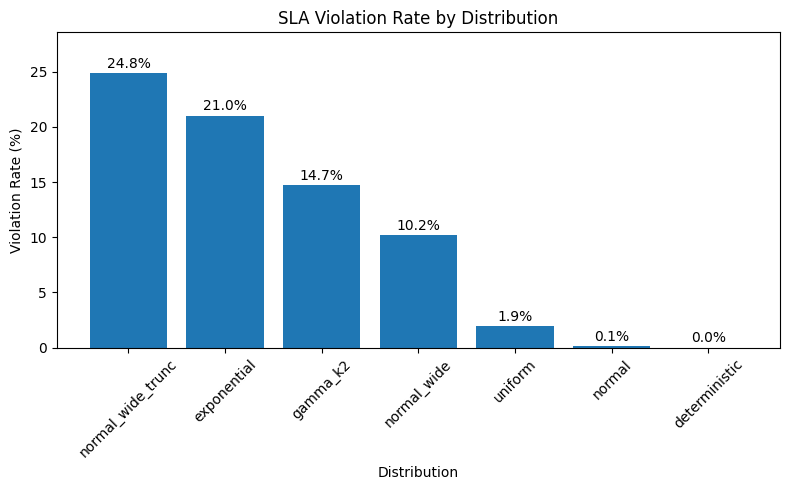

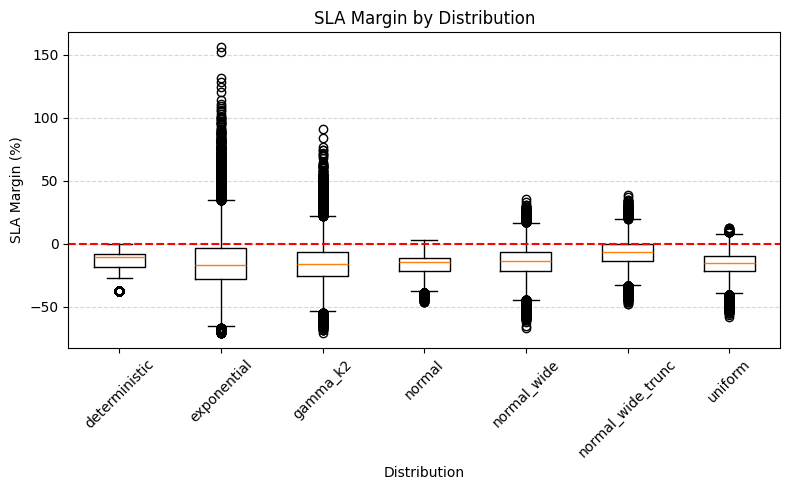

In [8]:
plot_df = dist_summary.sort_values('Violation_Rate', ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(plot_df['Distribution'], plot_df['Violation_Rate'])
plt.title('SLA Violation Rate by Distribution')
plt.xlabel('Distribution')
plt.xticks(rotation=45)
plt.ylabel('Violation Rate (%)')
plt.ylim(0, max(plot_df['Violation_Rate'].max() * 1.15, 5))

for i, v in enumerate(plot_df['Violation_Rate']):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

categories = sorted(df['Distribution'].dropna().unique())
data = [df.loc[df['Distribution'] == c, 'SLA_Margin_Perc'].dropna() for c in categories]

plt.figure(figsize=(8, 5))
plt.boxplot(data, tick_labels=categories)
plt.title('SLA Margin by Distribution')
plt.xlabel('Distribution')
plt.ylabel('SLA Margin (%)')

plt.axhline(0, linestyle='--', color='red')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

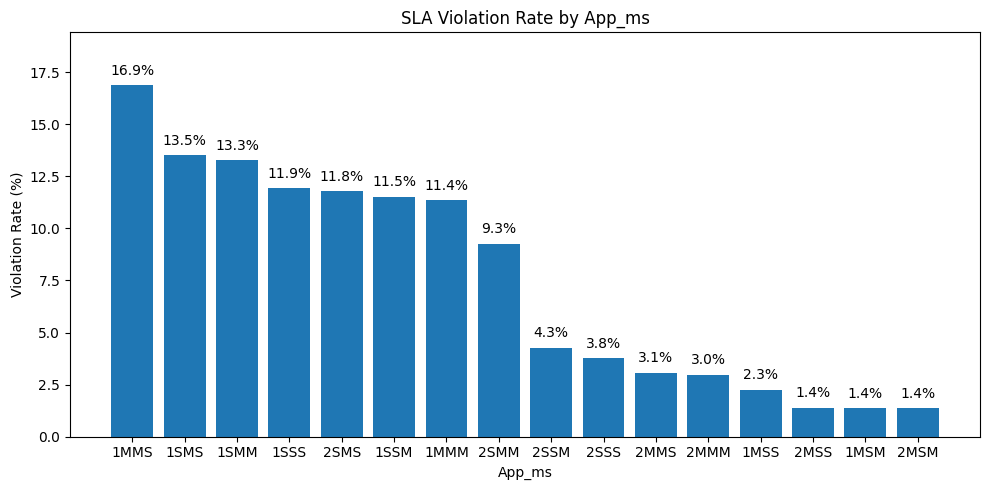

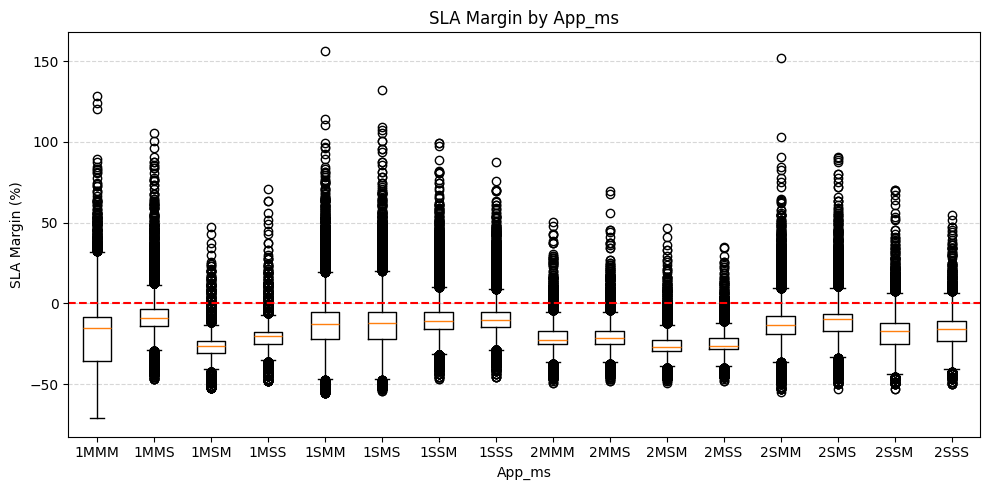

In [9]:
plot_df = app_summary.sort_values('Violation_Rate', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df['App_ms'], plot_df['Violation_Rate'])
plt.title('SLA Violation Rate by App_ms')
plt.xlabel('App_ms')
plt.ylabel('Violation Rate (%)')
plt.ylim(0, max(plot_df['Violation_Rate'].max() * 1.15, 5))

for i, v in enumerate(plot_df['Violation_Rate']):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

categories = sorted(df['App_ms'].dropna().unique())
data = [df.loc[df['App_ms'] == c, 'SLA_Margin_Perc'].dropna() for c in categories]

plt.figure(figsize=(10, 5))
plt.boxplot(data, tick_labels=categories)
plt.title('SLA Margin by App_ms')
plt.xlabel('App_ms')
plt.ylabel('SLA Margin (%)')

plt.axhline(0, linestyle='--', color='red')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

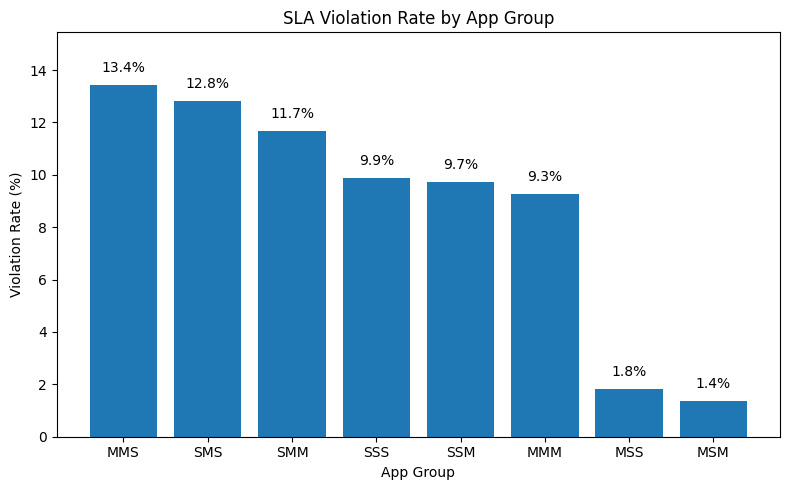

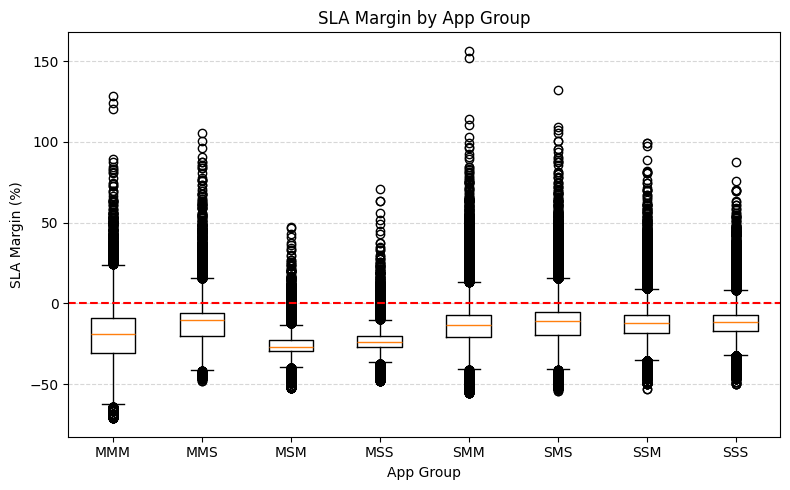

In [10]:
plot_df = app_group_summary.sort_values('Violation_Rate', ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(plot_df['App_group'], plot_df['Violation_Rate'])
plt.title('SLA Violation Rate by App Group')
plt.xlabel('App Group')
plt.ylabel('Violation Rate (%)')
plt.ylim(0, max(plot_df['Violation_Rate'].max() * 1.15, 5))

for i, v in enumerate(plot_df['Violation_Rate']):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

categories = sorted(df['App_group'].dropna().unique())
data = [df.loc[df['App_group'] == c, 'SLA_Margin_Perc'].dropna() for c in categories]

plt.figure(figsize=(8, 5))
plt.boxplot(data, tick_labels=categories)
plt.title('SLA Margin by App Group')
plt.xlabel('App Group')
plt.ylabel('SLA Margin (%)')

plt.axhline(0, linestyle='--', color='red')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

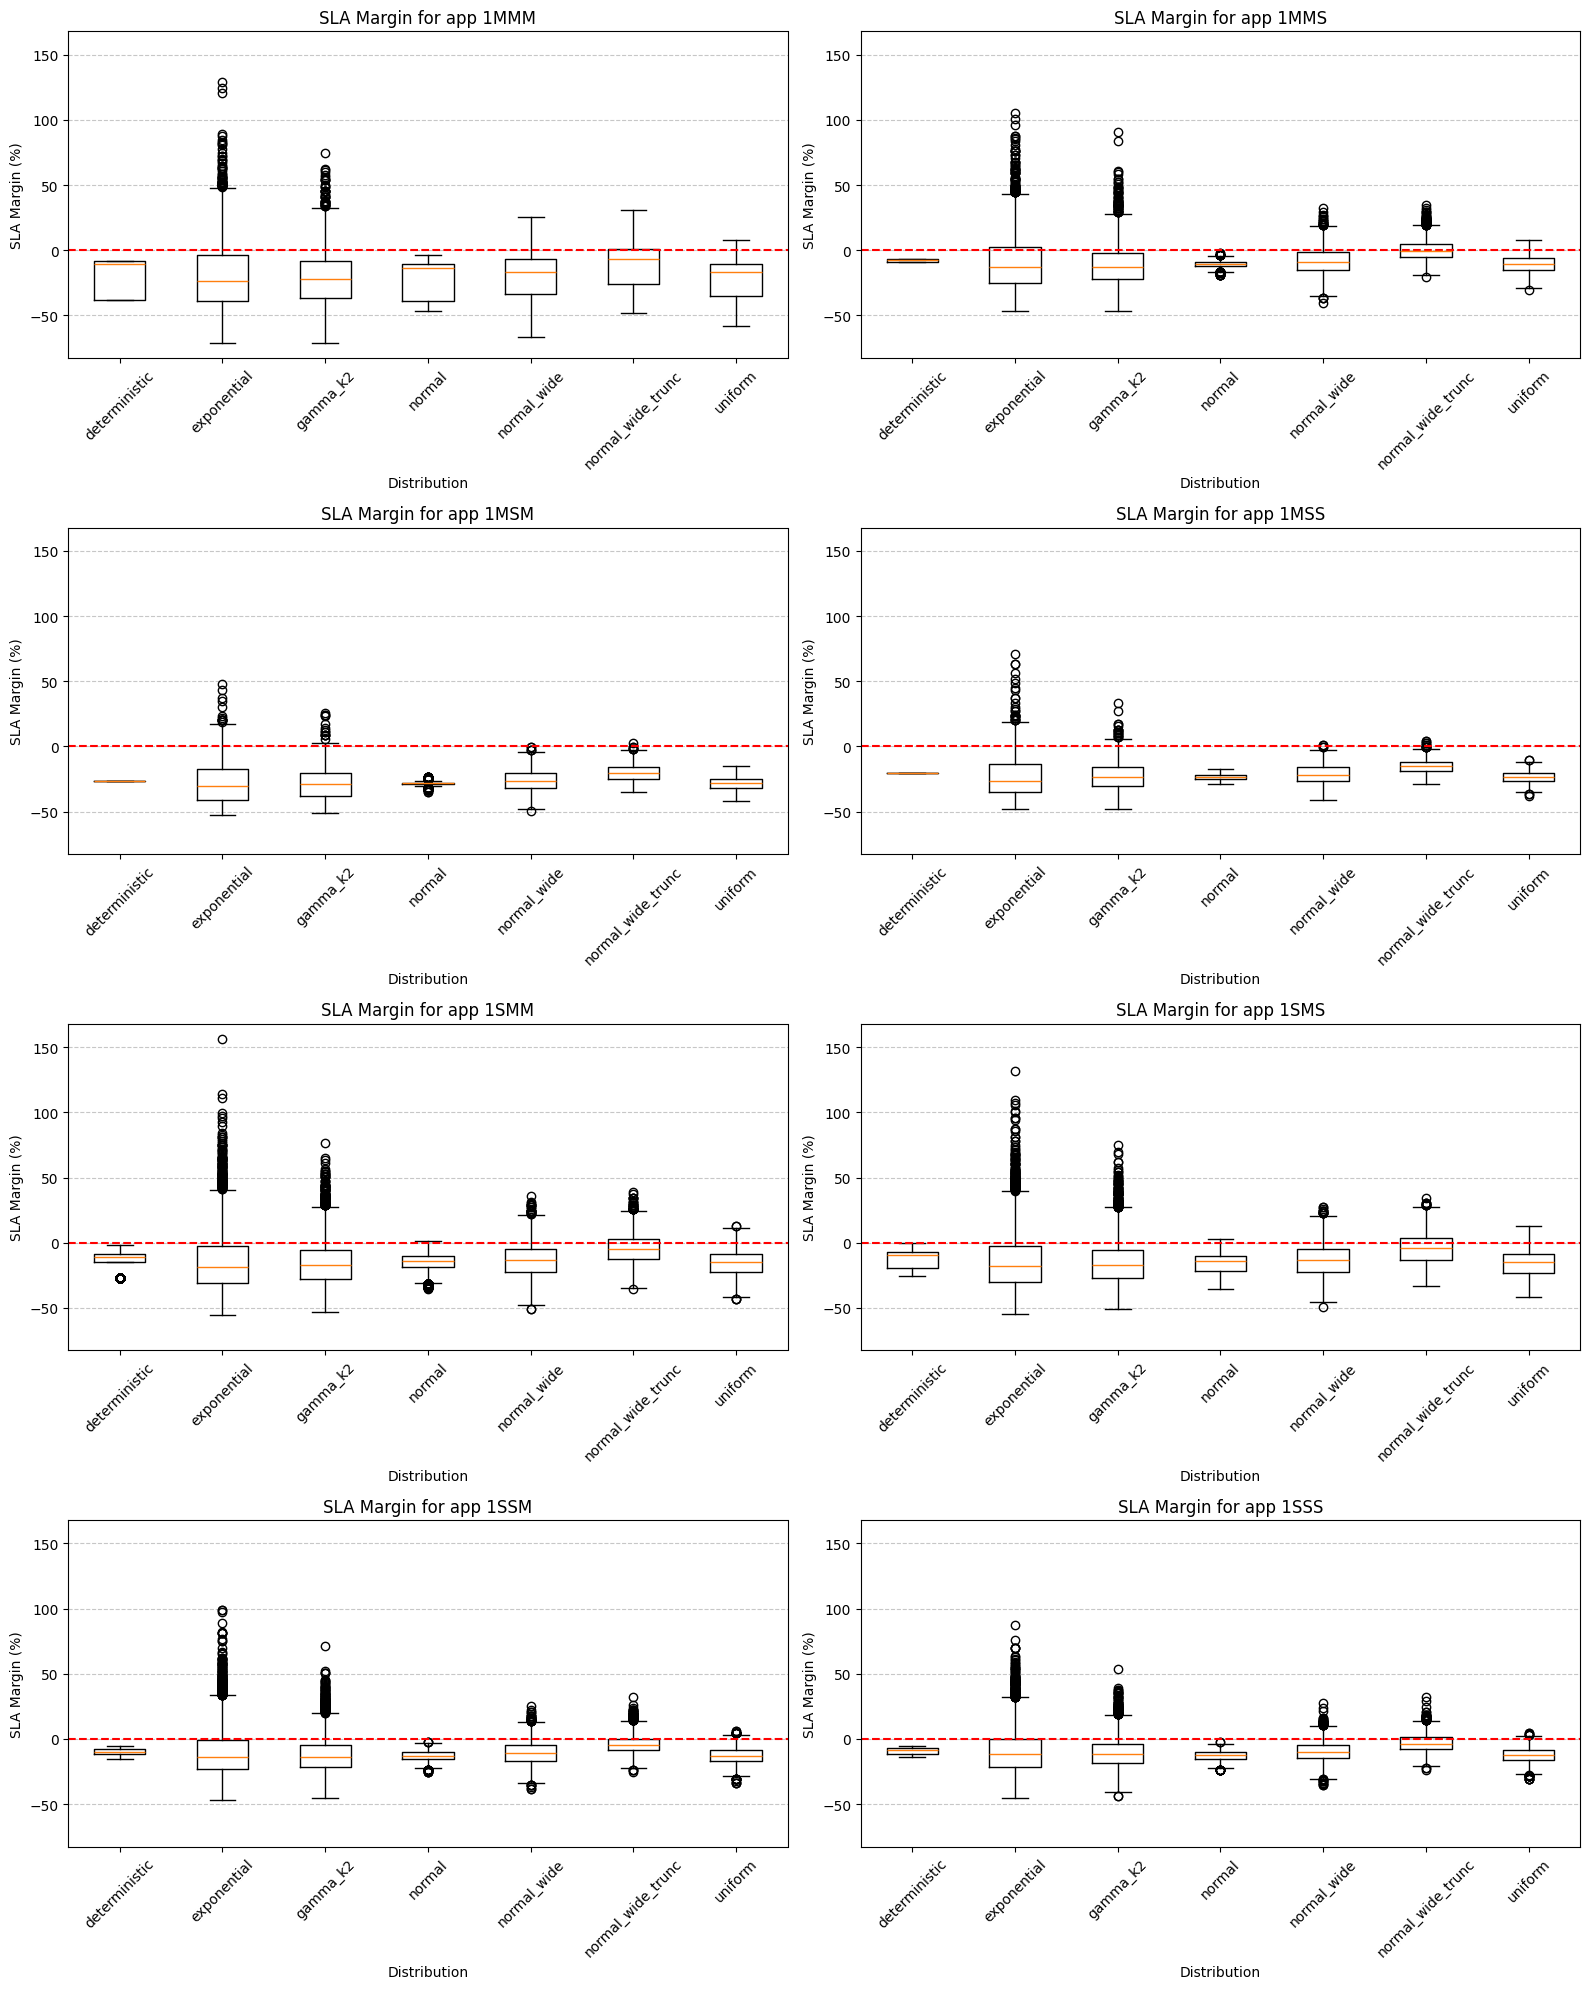

In [11]:
categories = sorted(df['Distribution'].dropna().unique())

apps_to_plot = sorted(df['App_ms'].dropna().unique())
apps_starting_with_1 = [app for app in apps_to_plot if str(app).startswith('1')]

num_apps = len(apps_starting_with_1)

ncols = 2
nrows = (num_apps + 1) // 2

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, nrows * 5))
axes = axes.flatten()

y_lower, y_upper = get_padded_ylim(df['SLA_Margin_Perc'])

for i, app in enumerate(apps_starting_with_1):
    ax = axes[i]
    df_app = df[df['App_ms'] == app]

    data = []
    labels = []

    for category in categories:
        subset = df_app.loc[df_app['Distribution'] == category, 'SLA_Margin_Perc'].dropna()
        if len(subset) > 0:
            data.append(subset)
            labels.append(category)

    ax.boxplot(data, tick_labels=labels)
    ax.axhline(0, linestyle='--', color='red')
    ax.set_ylim(y_lower, y_upper)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_title(f'SLA Margin for app {app}')
    ax.set_xlabel('Distribution')
    ax.set_ylabel('SLA Margin (%)')
    ax.tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

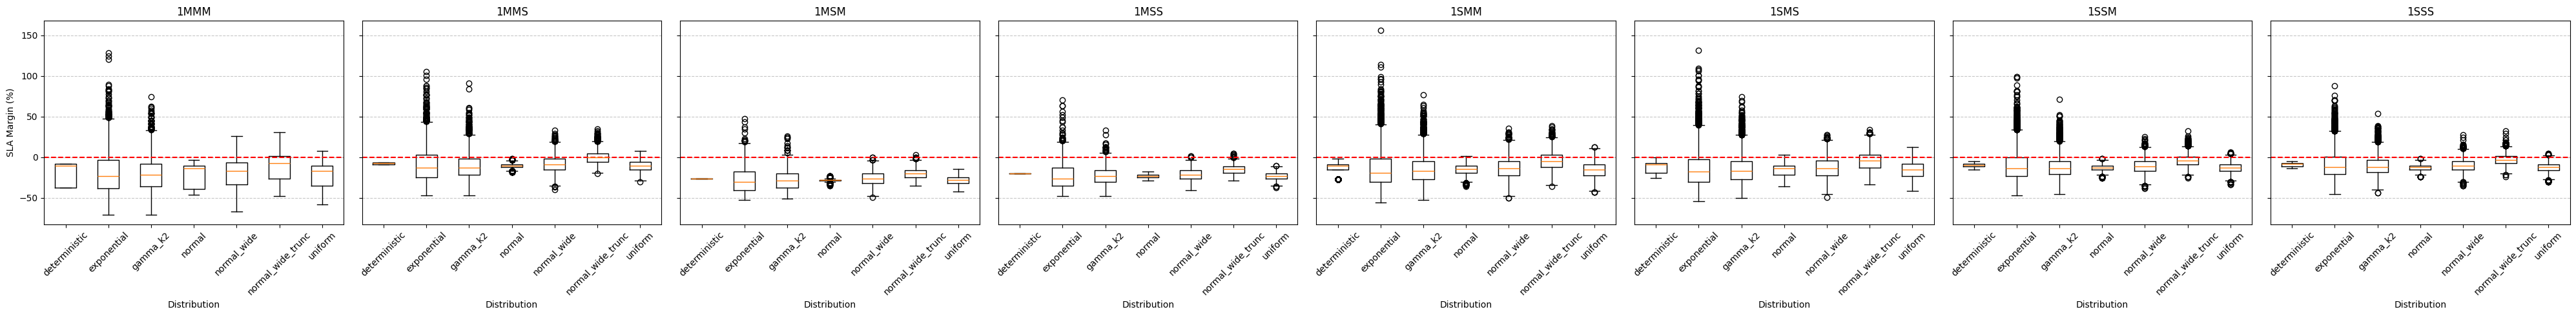

In [12]:
categories = sorted(df['Distribution'].dropna().unique())

apps_to_plot = sorted(df['App_ms'].dropna().unique())
apps_starting_with_1 = [app for app in apps_to_plot if str(app).startswith('1')]

num_apps = len(apps_starting_with_1)

fig, axes = plt.subplots(1, num_apps, sharey=True, figsize=(5 * num_apps, 5))

if num_apps == 1:
    axes = [axes]

y_lower, y_upper = get_padded_ylim(df['SLA_Margin_Perc'])

for i, app in enumerate(apps_starting_with_1):
    ax = axes[i]
    df_app = df[df['App_ms'] == app]

    data = []
    labels = []

    for category in categories:
        subset = df_app.loc[df_app['Distribution'] == category, 'SLA_Margin_Perc'].dropna()
        if len(subset) > 0:
            data.append(subset)
            labels.append(category)

    ax.boxplot(data, tick_labels=labels)
    ax.axhline(0, linestyle='--', color='red')
    ax.set_ylim(y_lower, y_upper)
    ax.set_title(app)
    ax.set_xlabel('Distribution')

    if i == 0:
        ax.set_ylabel('SLA Margin (%)')

    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

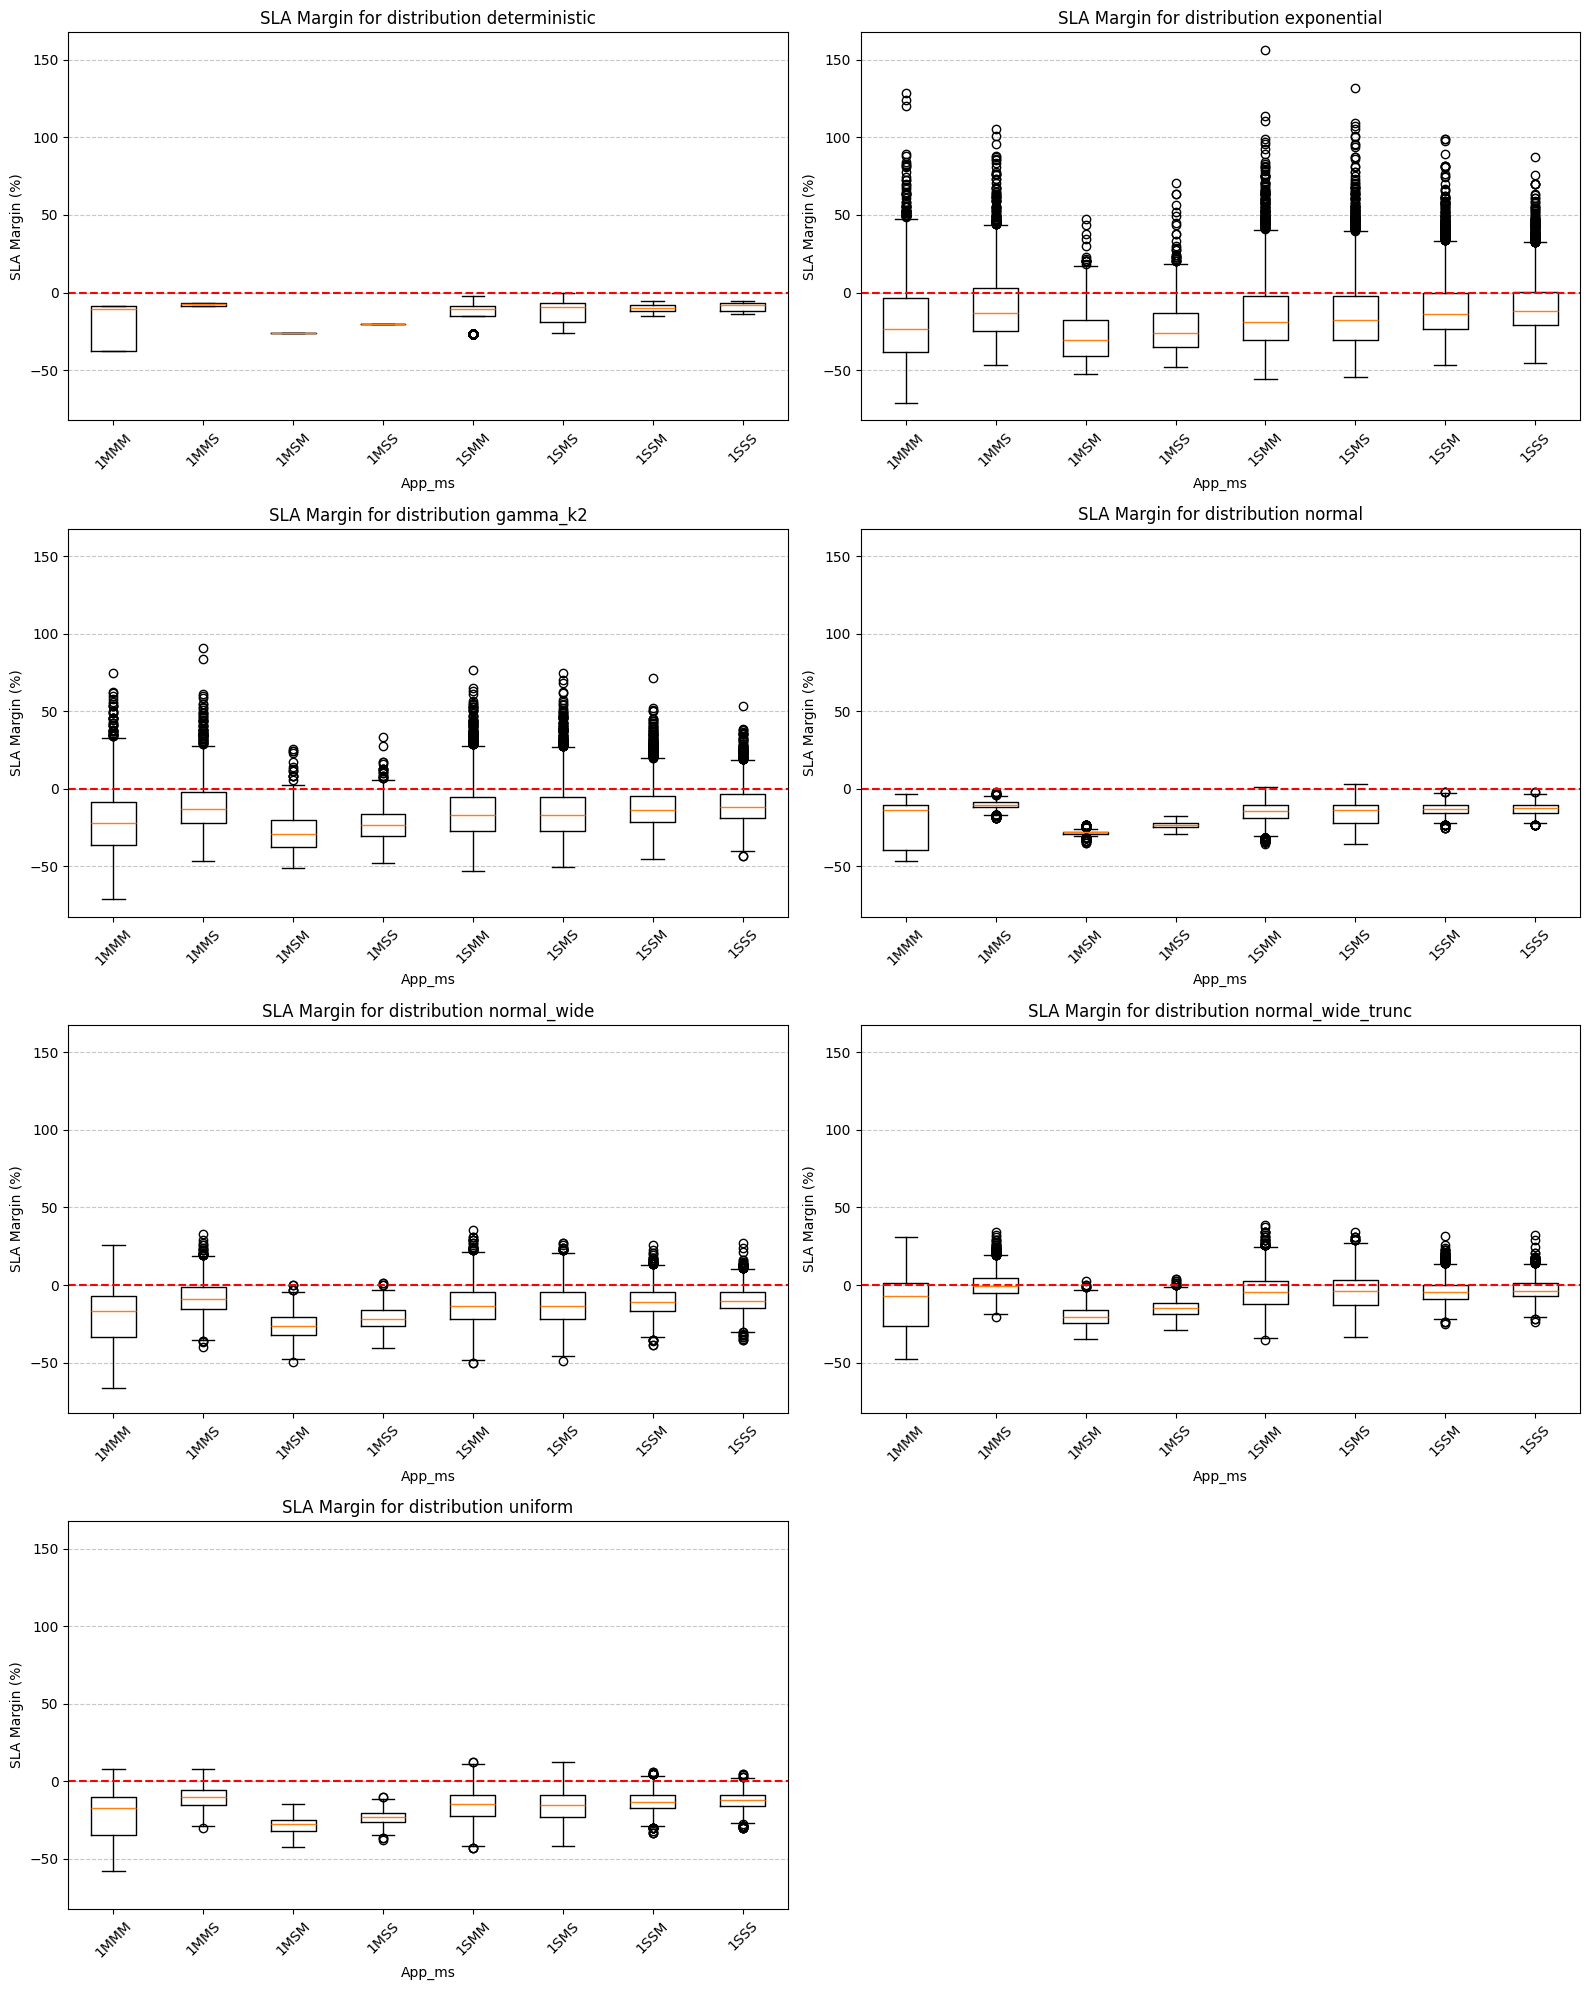

In [13]:
distributions = sorted(df['Distribution'].dropna().unique())

apps_to_plot = sorted(df['App_ms'].dropna().unique())
apps_starting_with_1 = [app for app in apps_to_plot if str(app).startswith('1')]

num_dist = len(distributions)

ncols = 2
nrows = (num_dist + 1) // 2

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, nrows * 5))
axes = axes.flatten()

y_min = df['SLA_Margin_Perc'].min()
y_max = df['SLA_Margin_Perc'].max()

y_lower, y_upper = get_padded_ylim(df['SLA_Margin_Perc'])

for i, dist in enumerate(distributions):
    ax = axes[i]
    df_dist = df[df['Distribution'] == dist]

    data = []
    labels = []

    for app in apps_starting_with_1:
        subset = df_dist.loc[df_dist['App_ms'] == app, 'SLA_Margin_Perc'].dropna()
        if len(subset) > 0:
            data.append(subset)
            labels.append(app)

    ax.boxplot(data, tick_labels=labels)#, showfliers=False)
    ax.axhline(0, linestyle='--', color='red')
    ax.set_ylim(y_lower, y_upper)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_title(f'SLA Margin for distribution {dist}')
    ax.set_xlabel('App_ms')
    ax.set_ylabel('SLA Margin (%)')
    ax.tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

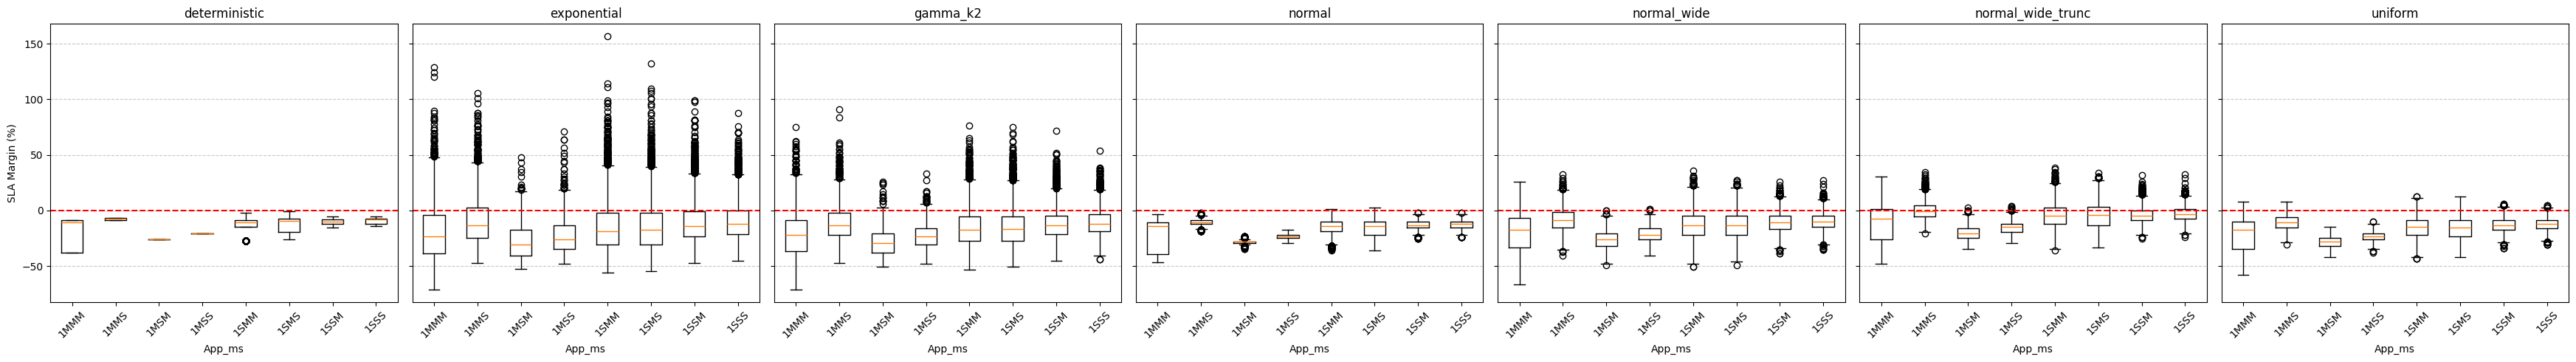

In [14]:
distributions = sorted(df['Distribution'].dropna().unique())

apps_to_plot = sorted(df['App_ms'].dropna().unique())
apps_starting_with_1 = [app for app in apps_to_plot if str(app).startswith('1')]

num_dist = len(distributions)

fig, axes = plt.subplots(1, num_dist, sharey=True, figsize=(5 * num_dist, 5))

if num_dist == 1:
    axes = [axes]

y_lower, y_upper = get_padded_ylim(df['SLA_Margin_Perc'])

for i, dist in enumerate(distributions):
    ax = axes[i]
    df_dist = df[df['Distribution'] == dist]

    data = []
    labels = []

    for app in apps_starting_with_1:
        subset = df_dist.loc[df_dist['App_ms'] == app, 'SLA_Margin_Perc'].dropna()
        if len(subset) > 0:
            data.append(subset)
            labels.append(app)

    ax.boxplot(data, tick_labels=labels)
    ax.axhline(0, linestyle='--', color='red')
    ax.set_ylim(y_lower, y_upper)
    ax.set_title(dist)
    ax.set_xlabel('App_ms')

    if i == 0:
        ax.set_ylabel('SLA Margin (%)')

    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

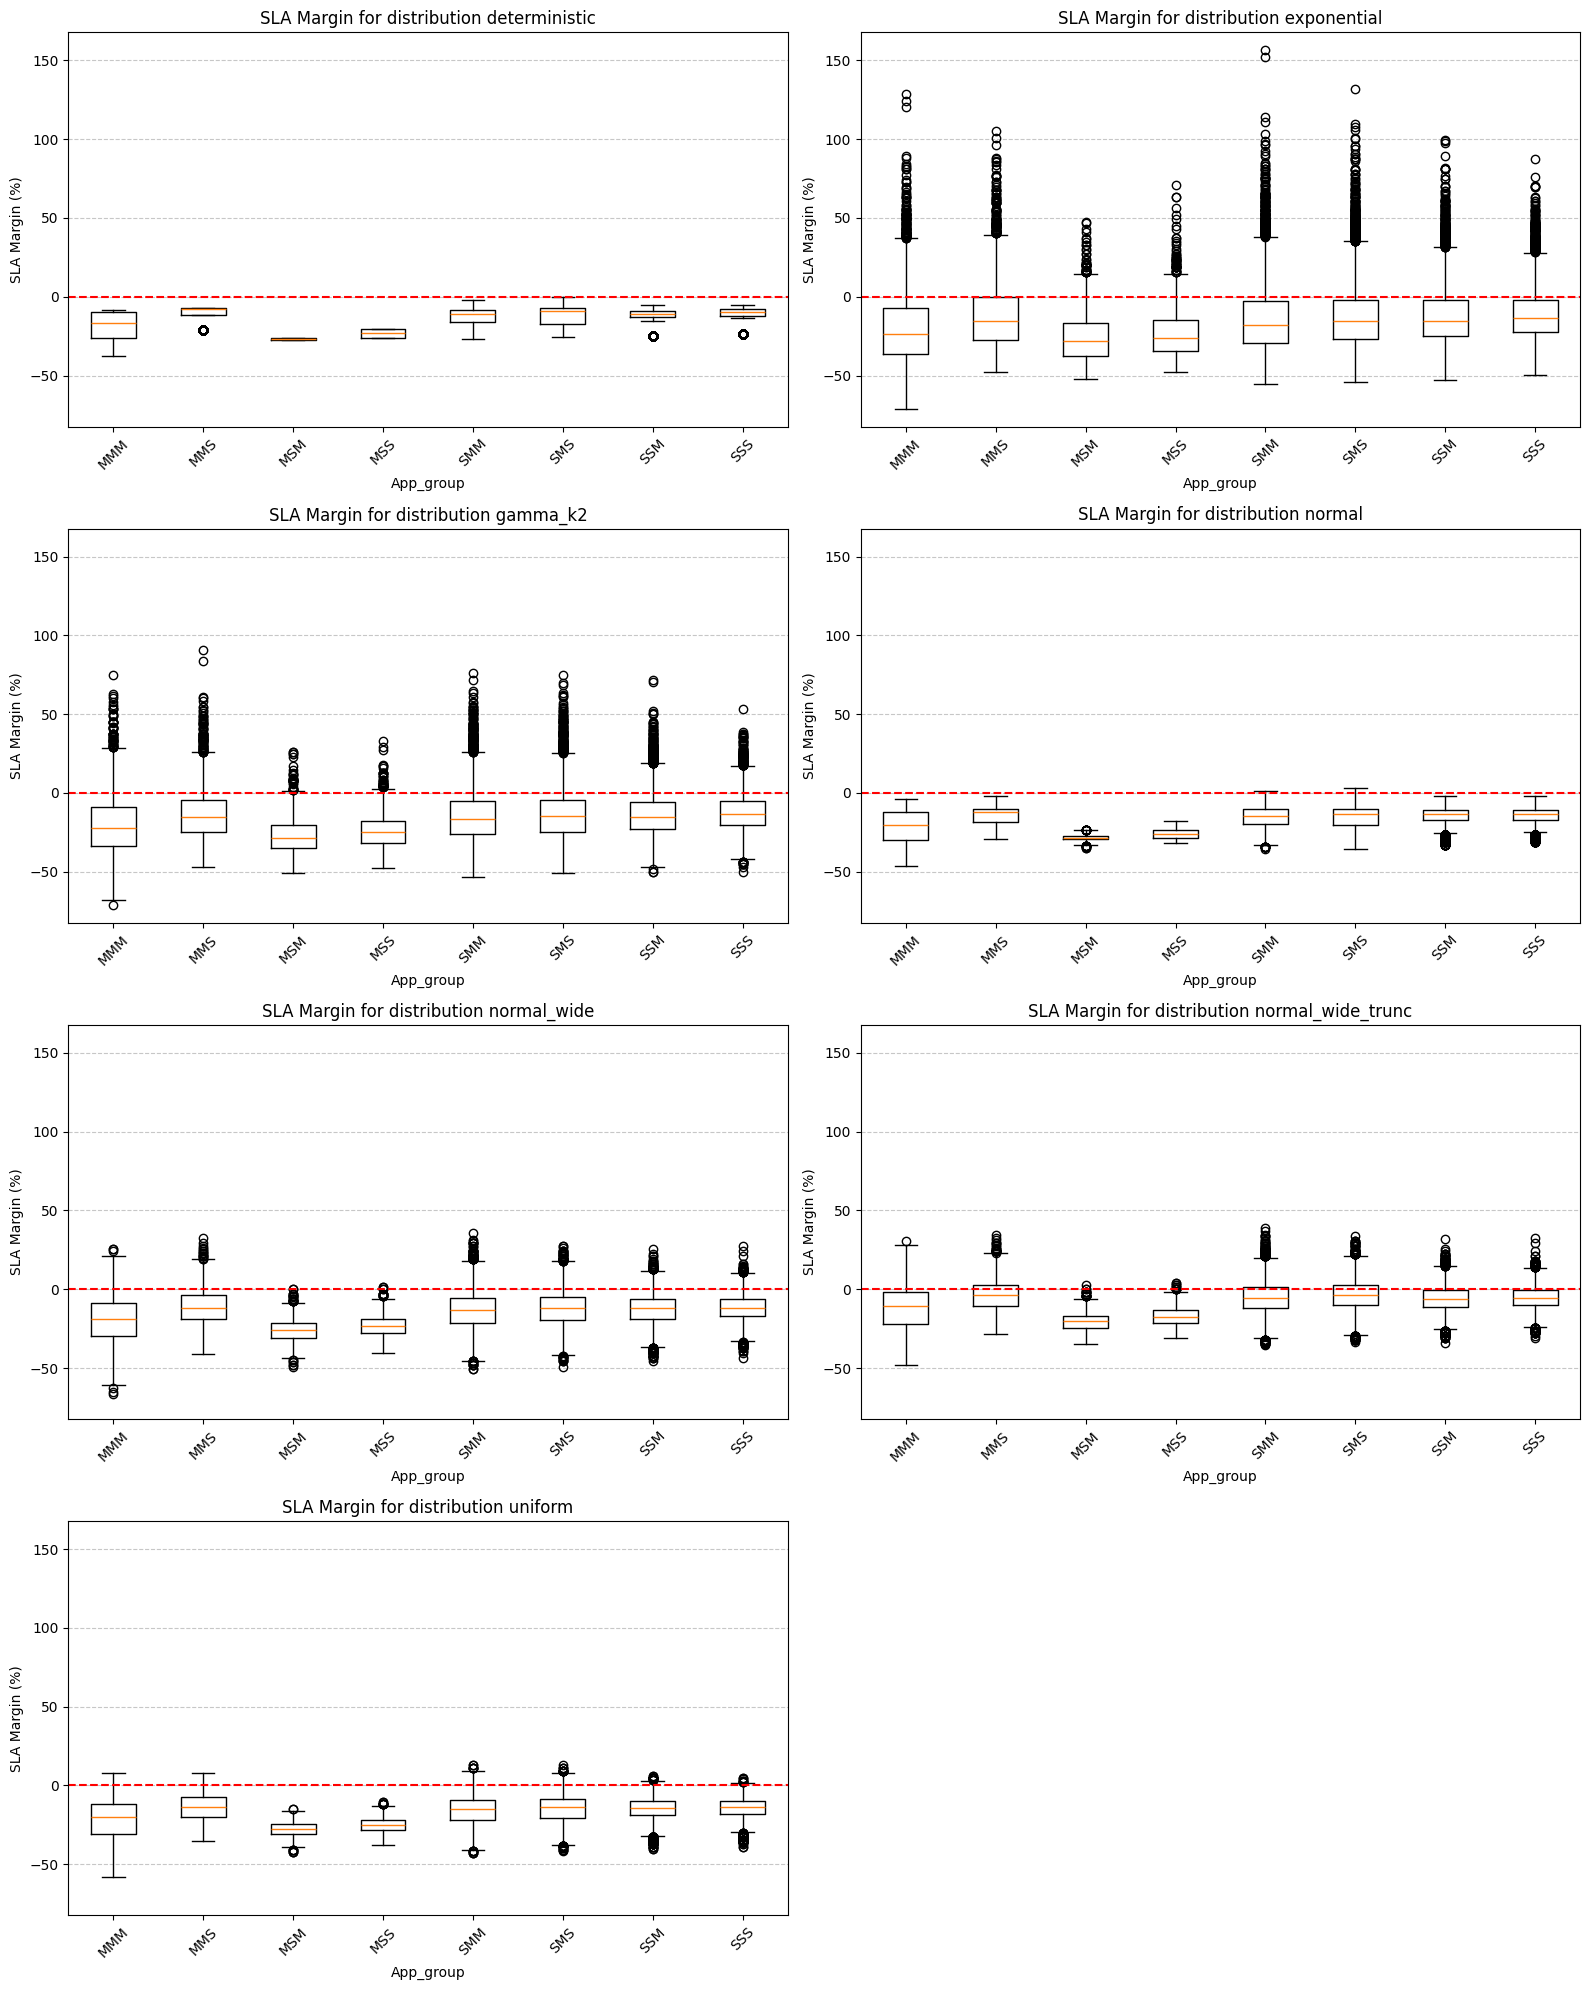

In [15]:
distributions = sorted(df['Distribution'].dropna().unique())

app_groups = sorted(df['App_group'].dropna().unique())

num_dist = len(distributions)

ncols = 2
nrows = (num_dist + 1) // 2

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, nrows * 5))
axes = axes.flatten()

y_lower, y_upper = get_padded_ylim(df['SLA_Margin_Perc'])

for i, dist in enumerate(distributions):
    ax = axes[i]
    df_dist = df[df['Distribution'] == dist]

    data = []
    labels = []

    for app_group in app_groups:
        subset = df_dist.loc[df_dist['App_group'] == app_group, 'SLA_Margin_Perc'].dropna()
        if len(subset) > 0:
            data.append(subset)
            labels.append(app_group)

    ax.boxplot(data, tick_labels=labels)
    ax.axhline(0, linestyle='--', color='red')
    ax.set_ylim(y_lower, y_upper)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_title(f'SLA Margin for distribution {dist}')
    ax.set_xlabel('App_group')
    ax.set_ylabel('SLA Margin (%)')
    ax.tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

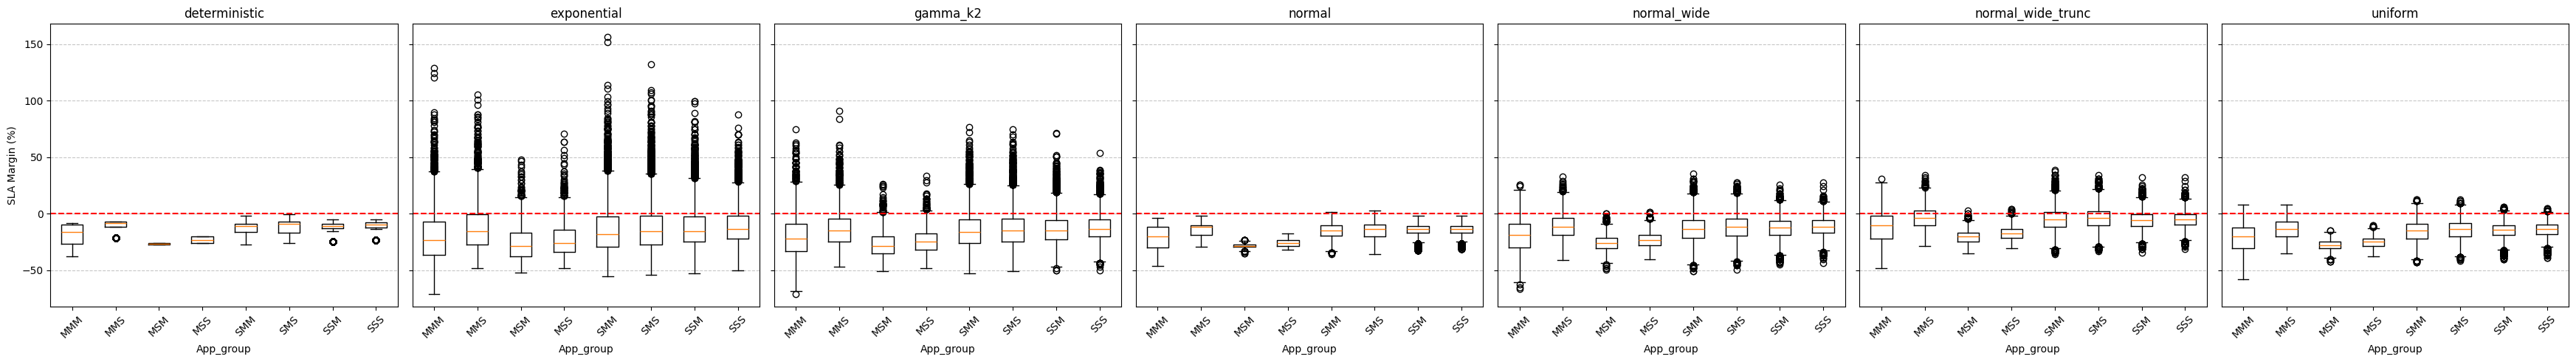

In [16]:
distributions = sorted(df['Distribution'].dropna().unique())

app_groups = sorted(df['App_group'].dropna().unique())

num_dist = len(distributions)

fig, axes = plt.subplots(1, num_dist, sharey=True, figsize=(5 * num_dist, 5))

if num_dist == 1:
    axes = [axes]

y_lower, y_upper = get_padded_ylim(df['SLA_Margin_Perc'])

for i, dist in enumerate(distributions):
    ax = axes[i]
    df_dist = df[df['Distribution'] == dist]

    data = []
    labels = []

    for app_group in app_groups:
        subset = df_dist.loc[df_dist['App_group'] == app_group, 'SLA_Margin_Perc'].dropna()
        if len(subset) > 0:
            data.append(subset)
            labels.append(app_group)

    ax.boxplot(data, tick_labels=labels)
    ax.axhline(0, linestyle='--', color='red')
    ax.set_ylim(y_lower, y_upper)
    ax.set_title(dist)
    ax.set_xlabel('App_group')

    if i == 0:
        ax.set_ylabel('SLA Margin (%)')

    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

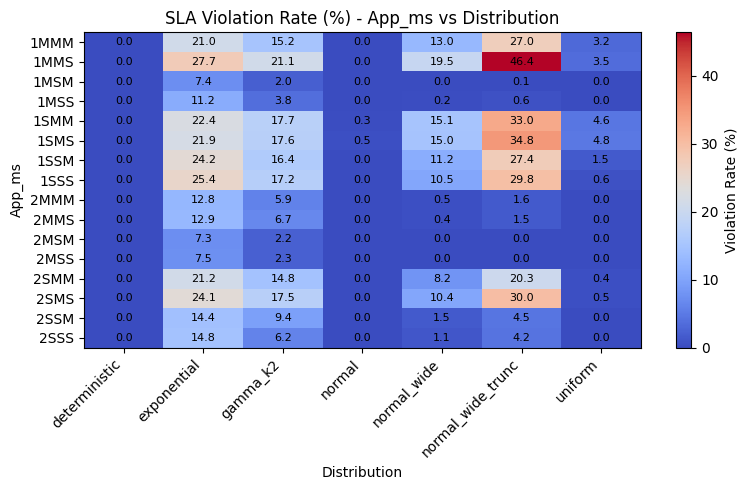

In [17]:
# percentage of run that have SLA violations

heatmap_data = (
    df.groupby(['App_ms', 'Distribution'])['SLA_Violation']
      .mean()
      .unstack() * 100
)

heatmap_data = heatmap_data.sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='coolwarm')

ax.set_title('SLA Violation Rate (%) - App_ms vs Distribution')
ax.set_xlabel('Distribution')
ax.set_ylabel('App_ms')

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha='right')

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.1f}", ha='center', va='center', fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Violation Rate (%)')

plt.tight_layout()
plt.show()

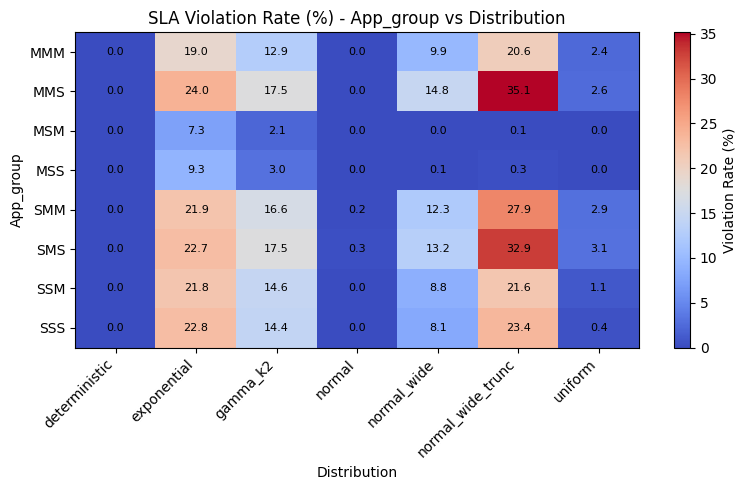

In [18]:
heatmap_data = (
    df.groupby(['App_group', 'Distribution'])['SLA_Violation']
      .mean()
      .unstack() * 100
)

heatmap_data = heatmap_data.sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='coolwarm')

ax.set_title('SLA Violation Rate (%) - App_group vs Distribution')
ax.set_xlabel('Distribution')
ax.set_ylabel('App_group')

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha='right')

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.1f}", ha='center', va='center', fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Violation Rate (%)')

plt.tight_layout()
plt.show()

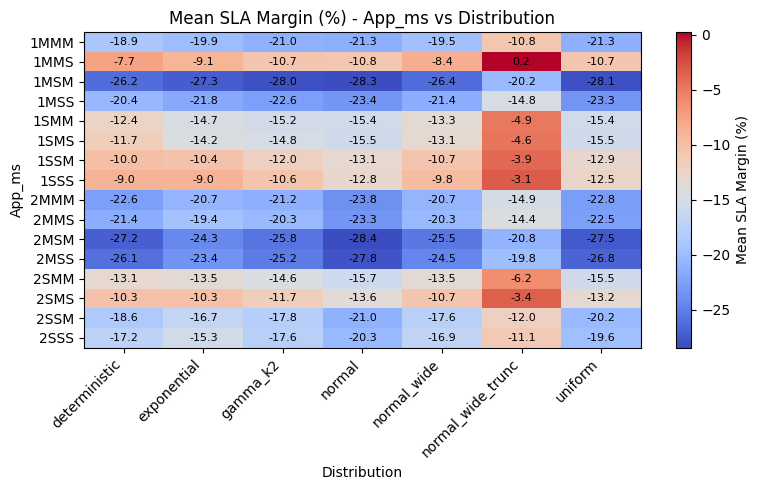

In [19]:
# mean percentage of SLA margin

heatmap_data = (
    df.groupby(['App_ms', 'Distribution'])['SLA_Margin_Perc']
      .mean()
      .unstack()
)

heatmap_data = heatmap_data.sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='coolwarm')

ax.set_title('Mean SLA Margin (%) - App_ms vs Distribution')
ax.set_xlabel('Distribution')
ax.set_ylabel('App_ms')

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha='right')

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.1f}", ha='center', va='center', fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Mean SLA Margin (%)')

plt.tight_layout()
plt.show()

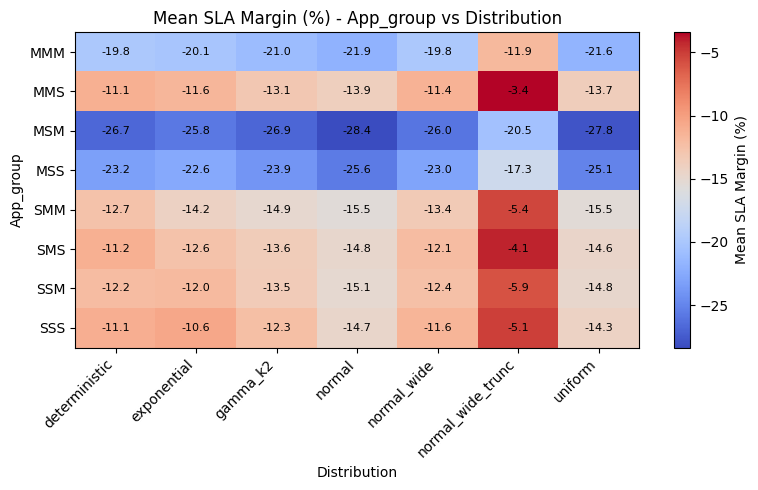

In [20]:
heatmap_data = (
    df.groupby(['App_group', 'Distribution'])['SLA_Margin_Perc']
      .mean()
      .unstack()
)

heatmap_data = heatmap_data.sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='coolwarm')

ax.set_title('Mean SLA Margin (%) - App_group vs Distribution')
ax.set_xlabel('Distribution')
ax.set_ylabel('App_group')

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha='right')

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.1f}", ha='center', va='center', fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Mean SLA Margin (%)')

plt.tight_layout()
plt.show()

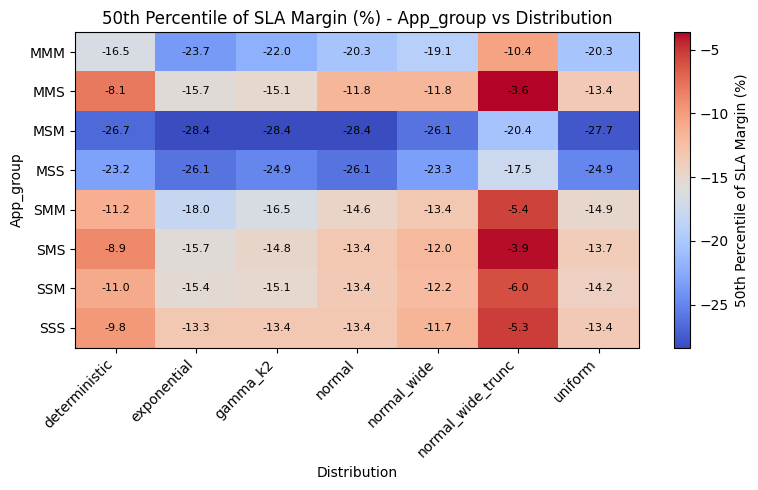

In [21]:
heatmap_data = (
    df.groupby(['App_group', 'Distribution'])['SLA_Margin_Perc']
      .quantile(0.50)
      .unstack()
)

heatmap_data = heatmap_data.sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='coolwarm')

ax.set_title('50th Percentile of SLA Margin (%) - App_group vs Distribution')
ax.set_xlabel('Distribution')
ax.set_ylabel('App_group')

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha='right')

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.1f}", ha='center', va='center', fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('50th Percentile of SLA Margin (%)')

plt.tight_layout()
plt.show()

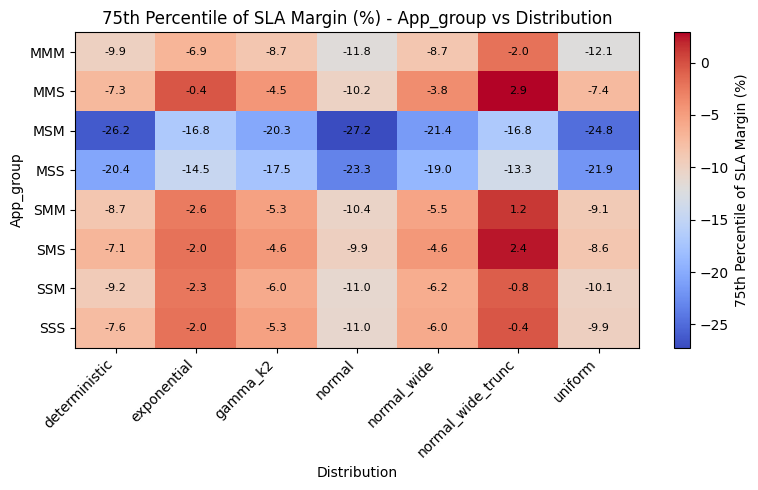

In [22]:
heatmap_data = (
    df.groupby(['App_group', 'Distribution'])['SLA_Margin_Perc']
      .quantile(0.75)
      .unstack()
)

heatmap_data = heatmap_data.sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='coolwarm')

ax.set_title('75th Percentile of SLA Margin (%) - App_group vs Distribution')
ax.set_xlabel('Distribution')
ax.set_ylabel('App_group')

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha='right')

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.1f}", ha='center', va='center', fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('75th Percentile of SLA Margin (%)')

plt.tight_layout()
plt.show()

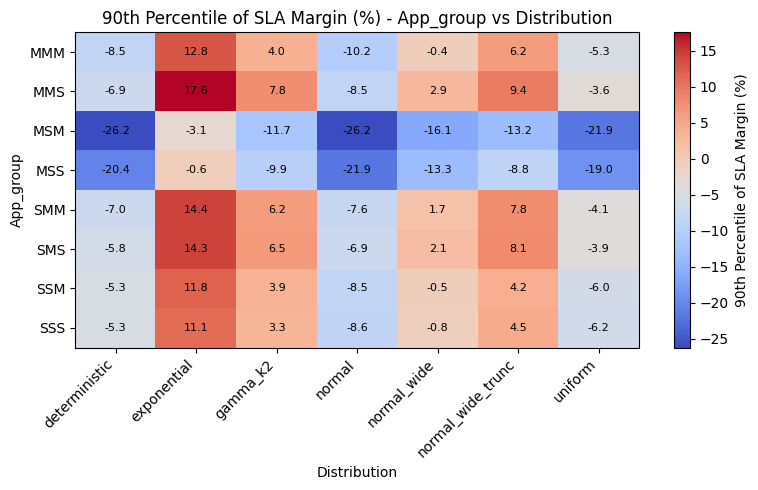

In [23]:
heatmap_data = (
    df.groupby(['App_group', 'Distribution'])['SLA_Margin_Perc']
      .quantile(0.90)
      .unstack()
)

heatmap_data = heatmap_data.sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='coolwarm')

ax.set_title('90th Percentile of SLA Margin (%) - App_group vs Distribution')
ax.set_xlabel('Distribution')
ax.set_ylabel('App_group')

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha='right')

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.1f}", ha='center', va='center', fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('90th Percentile of SLA Margin (%)')

plt.tight_layout()
plt.show()

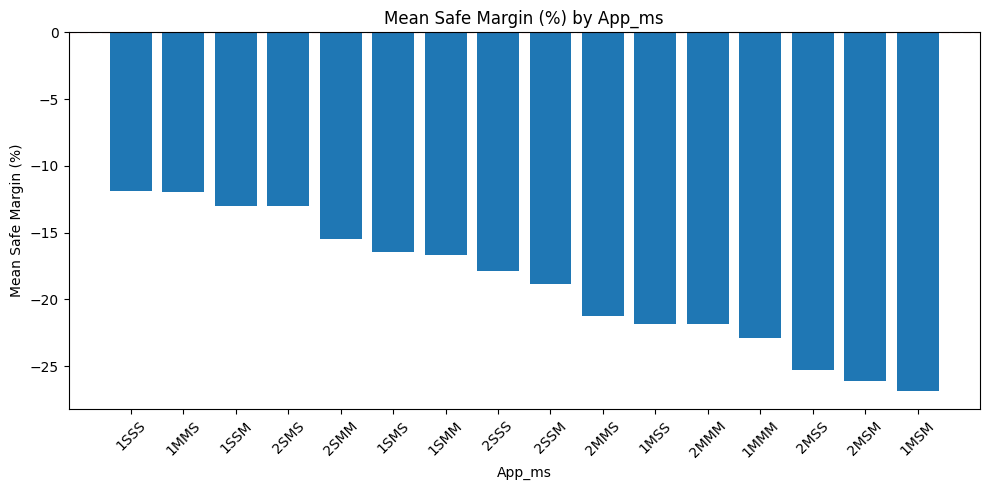

In [24]:
plot_df = app_summary.sort_values('Mean_Safe_Margin_Perc', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df['App_ms'], plot_df['Mean_Safe_Margin_Perc'])
plt.axhline(0, linestyle='--', color='red')
plt.title('Mean Safe Margin (%) by App_ms')
plt.xlabel('App_ms')
plt.ylabel('Mean Safe Margin (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

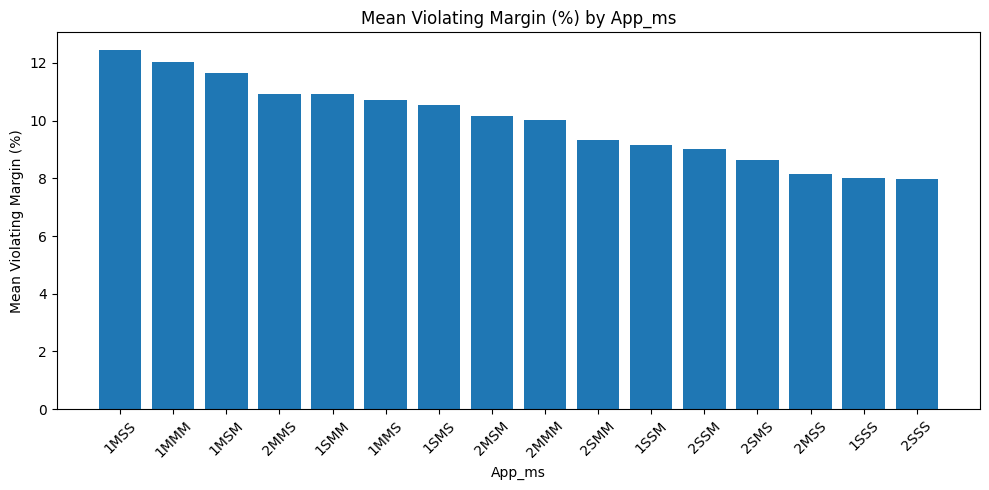

In [25]:
plot_df = app_summary.sort_values('Mean_Violating_Margin_Perc', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df['App_ms'], plot_df['Mean_Violating_Margin_Perc'])
plt.title('Mean Violating Margin (%) by App_ms')
plt.xlabel('App_ms')
plt.ylabel('Mean Violating Margin (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

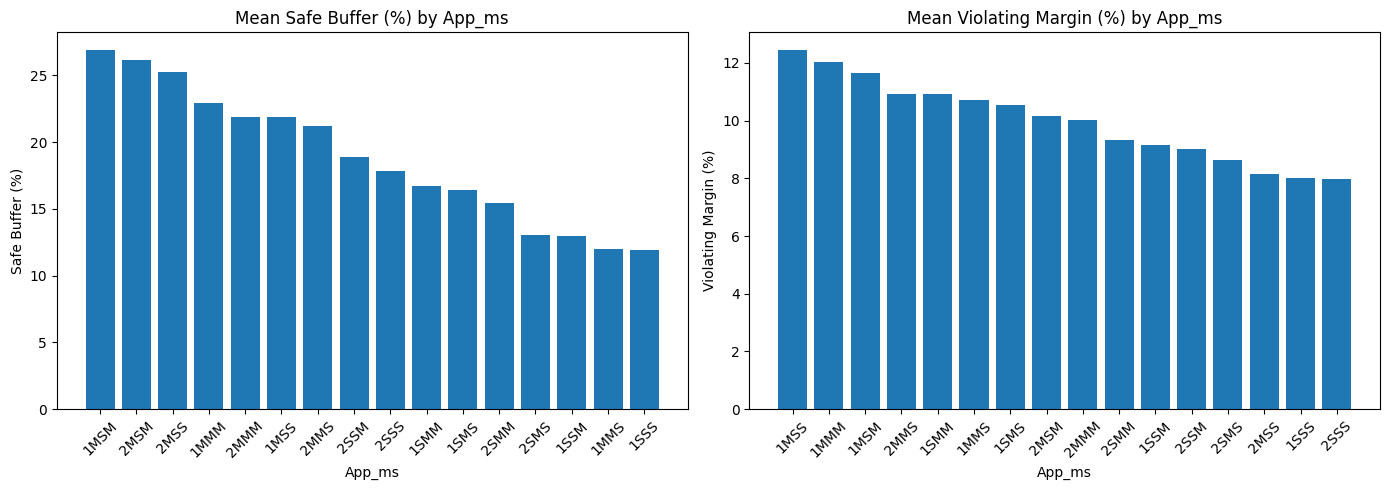

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df_safe = app_summary.copy()
plot_df_safe['Safe_Buffer_Perc'] = -plot_df_safe['Mean_Safe_Margin_Perc']
plot_df_safe = plot_df_safe.sort_values('Safe_Buffer_Perc', ascending=False)

axes[0].bar(plot_df_safe['App_ms'], plot_df_safe['Safe_Buffer_Perc'])
axes[0].set_title('Mean Safe Buffer (%) by App_ms')
axes[0].set_xlabel('App_ms')
axes[0].set_ylabel('Safe Buffer (%)')
axes[0].tick_params(axis='x', rotation=45)

plot_df_viol = app_summary.sort_values('Mean_Violating_Margin_Perc', ascending=False)
axes[1].bar(plot_df_viol['App_ms'], plot_df_viol['Mean_Violating_Margin_Perc'])
axes[1].set_title('Mean Violating Margin (%) by App_ms')
axes[1].set_xlabel('App_ms')
axes[1].set_ylabel('Violating Margin (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

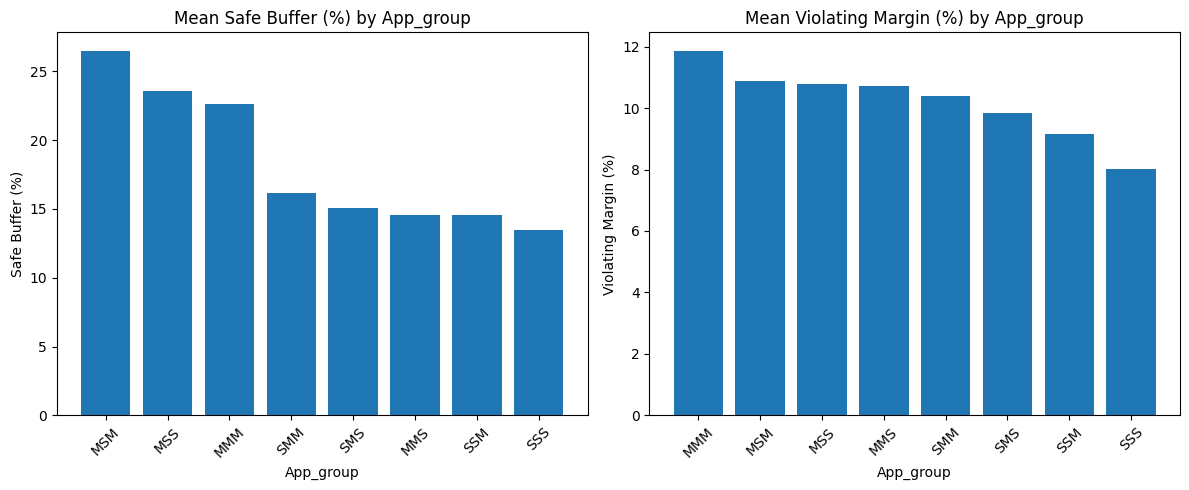

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_df_safe = app_group_summary.copy()
plot_df_safe['Safe_Buffer_Perc'] = -plot_df_safe['Mean_Safe_Margin_Perc']
plot_df_safe = plot_df_safe.sort_values('Safe_Buffer_Perc', ascending=False)

axes[0].bar(plot_df_safe['App_group'], plot_df_safe['Safe_Buffer_Perc'])
axes[0].set_title('Mean Safe Buffer (%) by App_group')
axes[0].set_xlabel('App_group')
axes[0].set_ylabel('Safe Buffer (%)')
axes[0].tick_params(axis='x', rotation=45)

plot_df_viol = app_group_summary.sort_values('Mean_Violating_Margin_Perc', ascending=False)
axes[1].bar(plot_df_viol['App_group'], plot_df_viol['Mean_Violating_Margin_Perc'])
axes[1].set_title('Mean Violating Margin (%) by App_group')
axes[1].set_xlabel('App_group')
axes[1].set_ylabel('Violating Margin (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

* **`Scenario`**: identificativo dello scenario considerato, cioè della specifica configurazione di rete e di placement analizzata.

* **`App_ms`**: identificativo completo dell’applicazione o catena di microservizi considerata.

* **`App_group`**: versione aggregata di `App_ms` che ignora il prefisso numerico iniziale e mantiene solo la struttura dell’applicazione.

* **`Node_Weight_Sum`**: somma dei pesi `c_i` dei nodi su cui sono stati deployati i servizi dell’applicazione, cioè il contributo del placement alla funzione obiettivo nella forma 

$$\sum_u \sum_i x_{ui} c_i$$

* **`Service_Weighted_Node_Weight_Sum`**: somma dei pesi dei nodi ulteriormente pesata con la domanda di CPU dei servizi, cioè il termine $$\sum_u \sum_i x_{ui} q_u c_i$$ Misura quindi il costo del placement tenendo conto anche della “dimensione” dei servizi.

* **`Num_Services`**: numero totale di servizi dell’applicazione che risultano effettivamente assegnati a un nodo.

* **`Used_Nodes_Count`**: numero di nodi distinti utilizzati per ospitare i servizi dell’applicazione.

* **`Zero_Cost_Used_Nodes`**: numero di nodi utilizzati che hanno peso `c_i = 0`, utile per verificare se il costo del placement è influenzato dalla presenza di nodi a costo nullo.


In [28]:
from analysis.utils.scenario_utils import build_objective_cost_dataset


objective_df = build_objective_cost_dataset()
objective_df

,Scenario,App_ms,App_group,Node_Weight_Sum,Service_Weighted_Node_Weight_Sum,Num_Services,Used_Nodes_Count,Zero_Cost_Used_Nodes
0,1_26_solution_v0,1SMM,SMM,0.318333,7.550000,6,4,1
1,1_26_solution_v0,1SMS,SMS,0.331667,7.643333,7,5,1
2,1_26_solution_v0,1SSM,SSM,0.168333,2.150000,7,5,2
3,1_26_solution_v0,1SSS,SSS,0.190000,1.851667,8,5,2
4,1_26_solution_v10,1MMM,MMM,0.290000,5.950000,5,3,1
5,1_26_solution_v10,1MMS,MMS,0.290000,5.950000,6,4,2
6,1_26_solution_v10,1MSM,MSM,0.116667,0.683333,6,4,2
7,1_26_solution_v10,1MSS,MSS,0.123333,0.696667,7,4,2
8,1_26_solution_v10,1SMM,SMM,0.290000,5.766667,6,4,2
9,1_26_solution_v10,1SMS,SMS,0.296667,5.866667,7,4,1


In [29]:
scatter_df = df.merge(
    objective_df,
    on=["Scenario", "App_ms", "App_group"],
    how="left"
)

scatter_df.head()

,Distribution,Scenario,App_ms,App_group,Run,User,Application,Total Delay,Delay SLAs,SLA_Violation,SLA_Margin,SLA_Margin_Perc,Violation_Amount,Processing Delay,Propagation Delay,Node_Weight_Sum,Service_Weighted_Node_Weight_Sum,Num_Services,Used_Nodes_Count,Zero_Cost_Used_Nodes
0,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_392,1,1,58,63.924,False,-5.924,-9.267,0.0,33,25,0.773889,12.444444,10,6,1
1,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_619,2,2,49,63.924,False,-14.924,-23.346,0.0,23,26,0.773889,12.444444,10,6,1
2,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_976,2,2,53,63.924,False,-10.924,-17.089,0.0,27,26,0.773889,12.444444,10,6,1
3,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_338,1,1,56,63.924,False,-7.924,-12.396,0.0,31,25,0.773889,12.444444,10,6,1
4,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_235,1,1,55,63.924,False,-8.924,-13.960,0.0,30,25,0.773889,12.444444,10,6,1


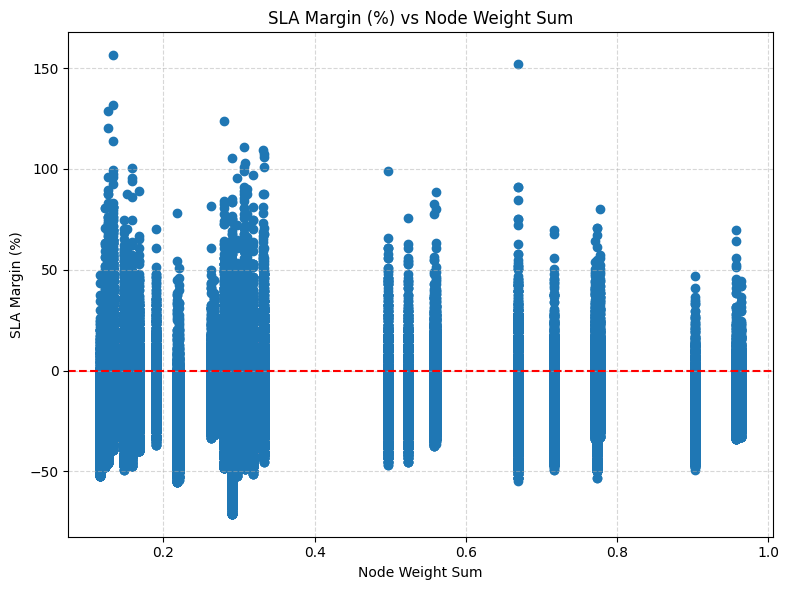

In [30]:
plt.figure(figsize=(8, 6))
plt.scatter(scatter_df["Node_Weight_Sum"], scatter_df["SLA_Margin_Perc"])

plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Node Weight Sum")
plt.ylabel("SLA Margin (%)")
plt.title("SLA Margin (%) vs Node Weight Sum")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

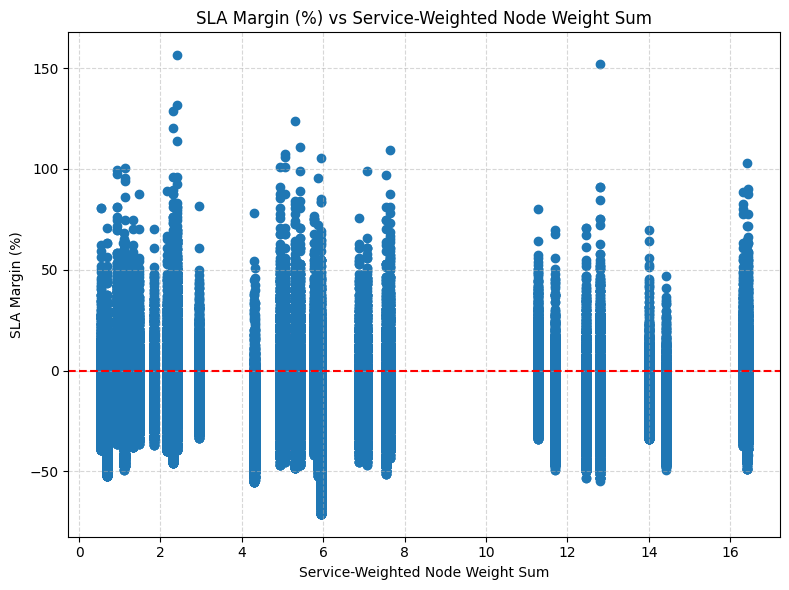

In [31]:
plt.figure(figsize=(8, 6))
plt.scatter(
    scatter_df["Service_Weighted_Node_Weight_Sum"],
    scatter_df["SLA_Margin_Perc"]
)

plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Service-Weighted Node Weight Sum")
plt.ylabel("SLA Margin (%)")
plt.title("SLA Margin (%) vs Service-Weighted Node Weight Sum")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [32]:
agg_scatter_df = (
    scatter_df.groupby("App_group")
    .agg(
        Mean_SLA_Margin_Perc=("SLA_Margin_Perc", "mean"),
        Mean_Node_Weight_Sum=("Node_Weight_Sum", "mean"),
        Mean_Service_Weighted_Node_Weight_Sum=("Service_Weighted_Node_Weight_Sum", "mean"),
    )
    .reset_index()
)

agg_scatter_df

,App_group,Mean_SLA_Margin_Perc,Mean_Node_Weight_Sum,Mean_Service_Weighted_Node_Weight_Sum
0,MMM,-19.446303,0.353333,6.312500
1,MMS,-11.181096,0.360000,6.221667
2,MSM,-26.003356,0.510000,7.558333
3,MSS,-22.949104,0.513333,7.565000
4,SMM,-13.080129,0.372056,8.338333
5,SMS,-11.856809,0.378889,8.325833
6,SSM,-12.252508,0.382986,5.173611
7,SSS,-11.373825,0.394236,5.203194


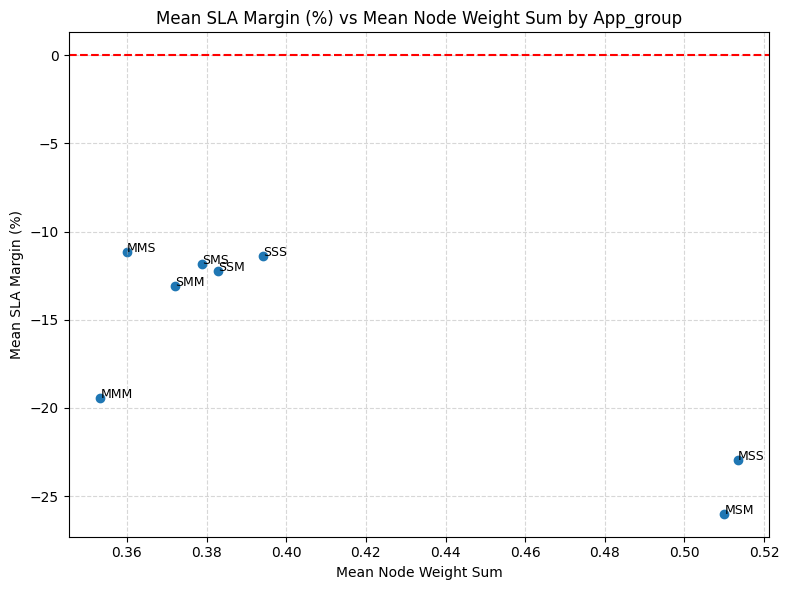

In [33]:
plt.figure(figsize=(8, 6))
plt.scatter(
    agg_scatter_df["Mean_Node_Weight_Sum"],
    agg_scatter_df["Mean_SLA_Margin_Perc"]
)

for _, row in agg_scatter_df.iterrows():
    plt.text(
        row["Mean_Node_Weight_Sum"],
        row["Mean_SLA_Margin_Perc"],
        row["App_group"],
        fontsize=9
    )

plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Mean Node Weight Sum")
plt.ylabel("Mean SLA Margin (%)")
plt.title("Mean SLA Margin (%) vs Mean Node Weight Sum by App_group")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

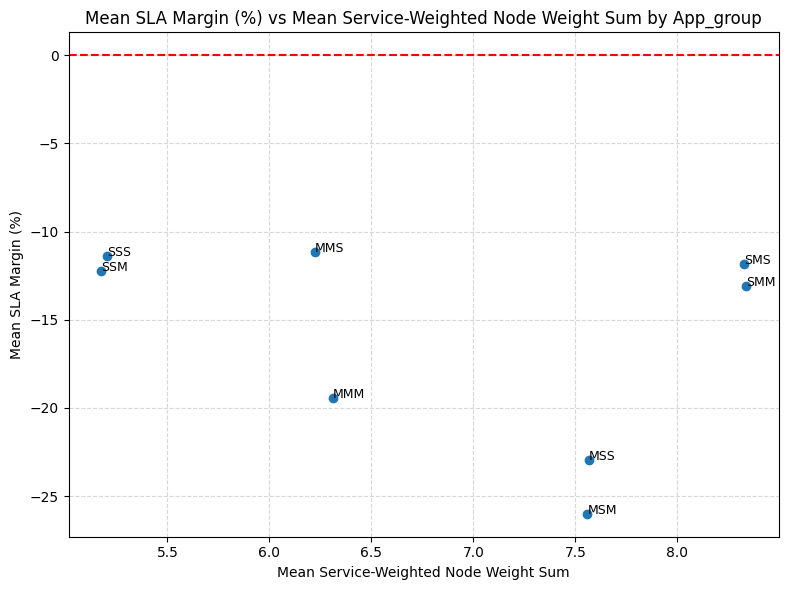

In [34]:
plt.figure(figsize=(8, 6))
plt.scatter(
    agg_scatter_df["Mean_Service_Weighted_Node_Weight_Sum"],
    agg_scatter_df["Mean_SLA_Margin_Perc"]
)

for _, row in agg_scatter_df.iterrows():
    plt.text(
        row["Mean_Service_Weighted_Node_Weight_Sum"],
        row["Mean_SLA_Margin_Perc"],
        row["App_group"],
        fontsize=9
    )

plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Mean Service-Weighted Node Weight Sum")
plt.ylabel("Mean SLA Margin (%)")
plt.title("Mean SLA Margin (%) vs Mean Service-Weighted Node Weight Sum by App_group")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [35]:
agg_df = (
    scatter_df.groupby(["Distribution", "App_group"])
    .agg(
        Mean_SLA_Margin_Perc=("SLA_Margin_Perc", "mean"),
        Median_SLA_Margin_Perc=("SLA_Margin_Perc", "median"),
        Violation_Rate=("SLA_Violation", "mean"),
        Mean_Node_Weight_Sum=("Node_Weight_Sum", "mean"),
        Mean_Service_Weighted_Node_Weight_Sum=("Service_Weighted_Node_Weight_Sum", "mean"),
        Mean_Zero_Cost_Used_Nodes=("Zero_Cost_Used_Nodes", "mean"),
    )
    .reset_index()
)

agg_df["Violation_Rate"] = agg_df["Violation_Rate"] * 100
agg_df.head()

,Distribution,App_group,Mean_SLA_Margin_Perc,Median_SLA_Margin_Perc,Violation_Rate,Mean_Node_Weight_Sum,Mean_Service_Weighted_Node_Weight_Sum,Mean_Zero_Cost_Used_Nodes
0,deterministic,MMM,-19.83200,-16.4990,0.0,0.353333,6.312500,0.75
1,deterministic,MMS,-11.12375,-8.0730,0.0,0.360000,6.221667,1.00
2,deterministic,MSM,-26.70900,-26.7090,0.0,0.510000,7.558333,1.50
3,deterministic,MSS,-23.23750,-23.2375,0.0,0.513333,7.565000,1.50
4,deterministic,SMM,-12.65070,-11.2355,0.0,0.372056,8.338333,1.00


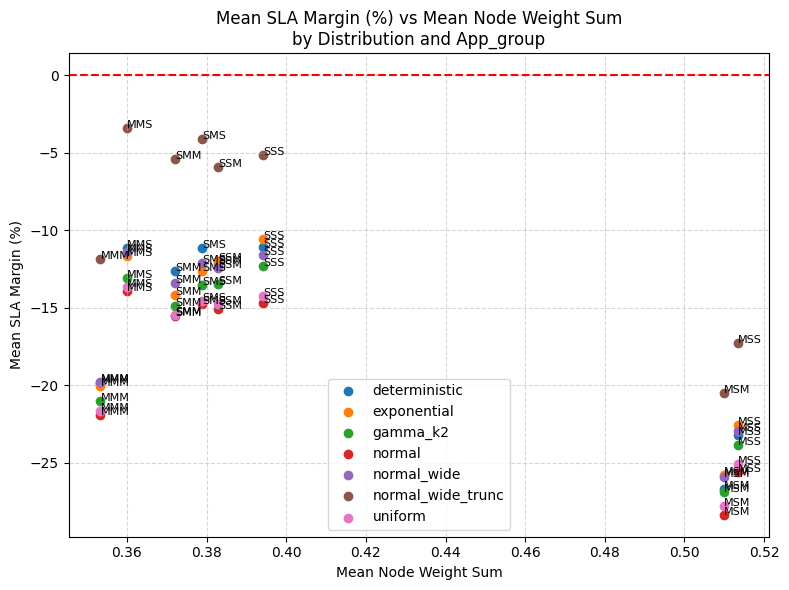

In [36]:
plt.figure(figsize=(8, 6))

for dist in sorted(agg_df["Distribution"].dropna().unique()):
    subset = agg_df[agg_df["Distribution"] == dist]
    plt.scatter(
        subset["Mean_Node_Weight_Sum"],
        subset["Mean_SLA_Margin_Perc"],
        label=dist
    )

    for _, row in subset.iterrows():
        plt.text(
            row["Mean_Node_Weight_Sum"],
            row["Mean_SLA_Margin_Perc"],
            row["App_group"],
            fontsize=8
        )

plt.axhline(0, linestyle="--", color="red")
plt.xlabel("Mean Node Weight Sum")
plt.ylabel("Mean SLA Margin (%)")
plt.title("Mean SLA Margin (%) vs Mean Node Weight Sum\nby Distribution and App_group")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

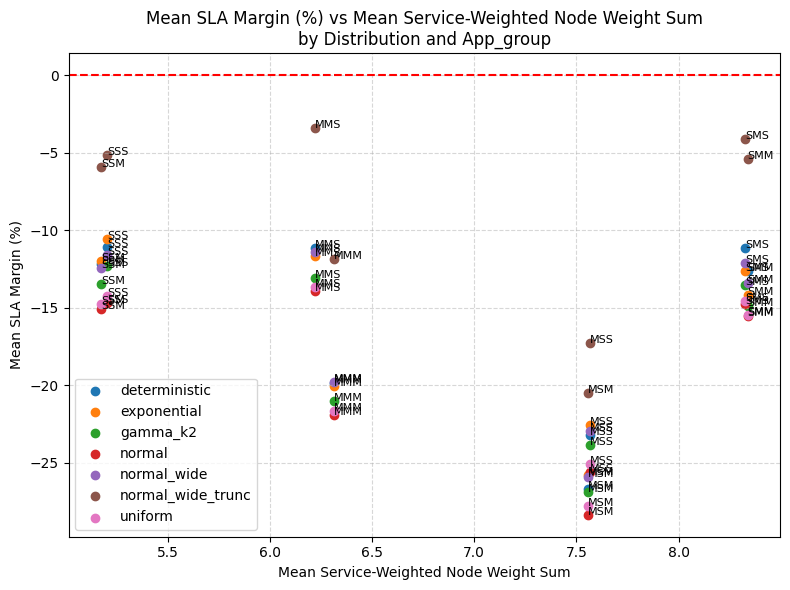

In [37]:
plt.figure(figsize=(8, 6))

for dist in sorted(agg_df["Distribution"].dropna().unique()):
    subset = agg_df[agg_df["Distribution"] == dist]
    plt.scatter(
        subset["Mean_Service_Weighted_Node_Weight_Sum"],
        subset["Mean_SLA_Margin_Perc"],
        label=dist
    )

    for _, row in subset.iterrows():
        plt.text(
            row["Mean_Service_Weighted_Node_Weight_Sum"],
            row["Mean_SLA_Margin_Perc"],
            row["App_group"],
            fontsize=8
        )

plt.axhline(0, linestyle="--", color="red")
plt.xlabel("Mean Service-Weighted Node Weight Sum")
plt.ylabel("Mean SLA Margin (%)")
plt.title("Mean SLA Margin (%) vs Mean Service-Weighted Node Weight Sum\nby Distribution and App_group")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()